In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**1. Epigenetic Mechanism Extraction(메커니즘 추출)**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Found .txt files in corpus folder: 6152
✅ Analyzed docs: 6152
ℹ️ Skipped docs (filter not matched): 0
✅ Saved outputs:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/mechanism_frequency_summary_6152.csv
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/assay_x_methylation_cooc_6152.csv
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/per_doc_mechanism_summary_6152.csv
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/mechanism_context_samples_6152.txt


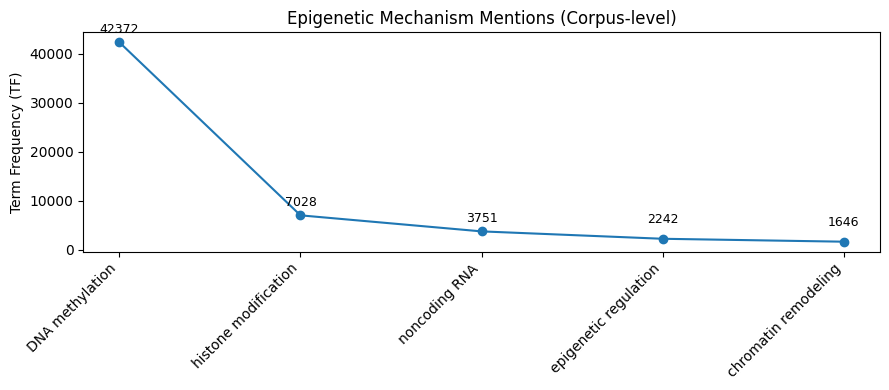

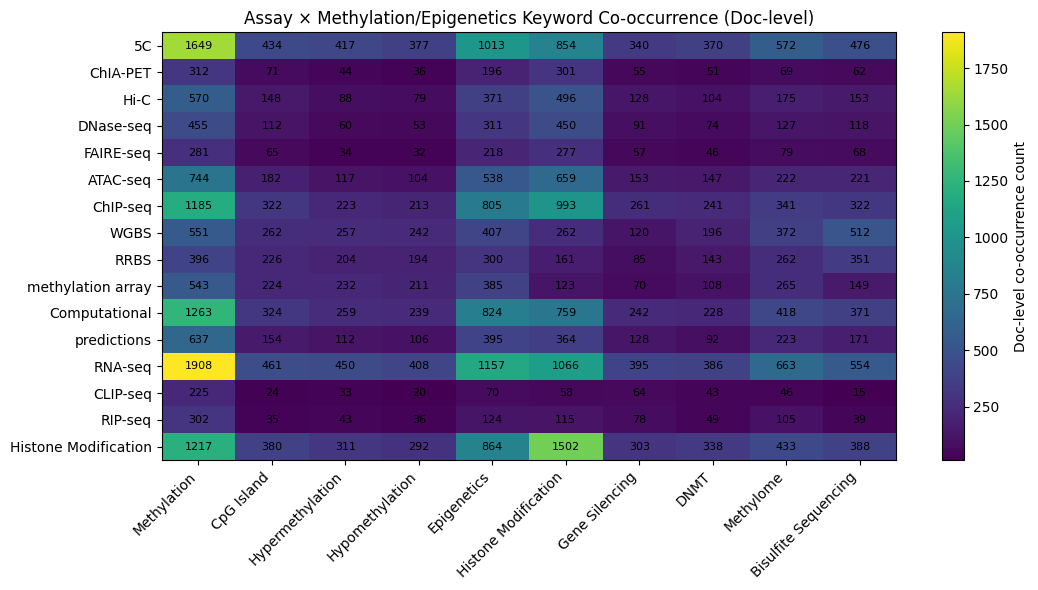

✅ Saved figures:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/FigureA_mechanism_TF_line_value_6152.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/FigureA_mechanism_TF_line_value_6152.pdf
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/FigureB_assay_x_methylation_heatmap_annot_6152.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/FigureB_assay_x_methylation_heatmap_annot_6152.pdf


In [ ]:
# 0) Google Drive 마운트 (Colab 환경에서 Drive 접근)
from google.colab import drive
drive.mount('/content/drive')

import os
import re
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) 경로 설정
# =========================
# CORPUS_DIR: .txt 논문(full-text) 파일들이 들어있는 폴더
# OUT_DIR: 결과 CSV/TXT/그림 파일을 저장할 폴더
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최죙)"
OUT_DIR = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126"
os.makedirs(OUT_DIR, exist_ok=True)  # 폴더가 없으면 생성

# =========================
# 2) 키워드 정의
# =========================
# assay_keywords: 실험/분석 기법(assay) 관련 키워드 리스트
assay_keywords = [
    "5C", "ChIA-PET", "Hi-C", "DNase-seq", "FAIRE-seq", "ATAC-seq", "ChIP-seq",
    "WGBS", "RRBS", "methylation array", "Computational", "predictions",
    "RNA-seq", "CLIP-seq", "RIP-seq", "Histone Modification"
]

# methylation_keywords: methylation/epigenetics 관련 개념 키워드 리스트
methylation_keywords = [
    "Methylation", "CpG Island", "Hypermethylation", "Hypomethylation",
    "Epigenetics", "Histone Modification", "Gene Silencing", "DNMT",
    "Methylome", "Bisulfite Sequencing"
]

# additional_keywords:
# - 문서 필터링용 키워드
# - [] 이면 필터 없이 전체 문서를 분석
# - 예: ["cancer", "brain"] 넣으면 해당 단어가 포함된 문서만 분석
additional_keywords = []

# mechanisms:
# - 메커니즘(핵심 개념)으로 보고 TF/DF 및 컨텍스트 문장을 추출할 키워드
mechanisms = [
    "DNA methylation",
    "histone modification",
    "chromatin remodeling",
    "noncoding RNA",
    "epigenetic regulation"
]

# 컨텍스트 문장(예시 문장) 수집 제한
MAX_CONTEXT_PER_MECH = 5               # 메커니즘 전체에서 최대 몇 문장까지 저장할지
MAX_CONTEXT_PER_DOC_PER_MECH = 3       # 문서 1개에서 메커니즘별 최대 몇 문장까지 저장할지

# =========================
# 3) 전처리 함수
# =========================
def normalize_text(t: str) -> str:
    """텍스트를 소문자 처리하고 공백을 정리하여 분석에 유리하게 정규화"""
    t = t.lower()
    t = re.sub(r"\s+", " ", t)
    return t

def split_sentences(text: str):
    """마침표/물음표/느낌표 기준으로 문장 분리"""
    return re.split(r"(?<=[.!?])\s+", text)

def count_keyword(text_norm: str, kw: str) -> int:
    """정규화된 텍스트에서 특정 키워드(문자열)가 등장하는 횟수(TF)를 계산"""
    return len(re.findall(re.escape(kw.lower()), text_norm))

def passes_filter(text_norm: str, filters) -> bool:
    """additional_keywords가 비어 있으면 True(필터 없음),
       비어있지 않으면 그 중 하나라도 문서에 포함될 때만 True"""
    if not filters:
        return True
    return any(f.lower() in text_norm for f in filters)

def extract_mechanisms_from_doc(doc_text: str):
    """문서 1개에서 mechanisms에 대한 TF와 컨텍스트 문장을 추출"""
    text_norm = normalize_text(doc_text)
    sents = split_sentences(text_norm)

    mech_tf = Counter()                 # 메커니즘별 TF(언급 횟수)
    mech_ctx = defaultdict(list)        # 메커니즘별 컨텍스트 문장 리스트

    for m in mechanisms:
        # 문서 전체에서 메커니즘 키워드가 등장한 횟수(TF)
        mech_tf[m] = count_keyword(text_norm, m)

        # TF>0이면, 해당 메커니즘이 들어간 문장들을 최대 MAX_CONTEXT_PER_DOC_PER_MECH개까지 저장
        if mech_tf[m] > 0:
            for s in sents:
                if m.lower() in s:
                    if len(mech_ctx[m]) < MAX_CONTEXT_PER_DOC_PER_MECH:
                        mech_ctx[m].append(s.strip())

    return mech_tf, mech_ctx

def load_txt_files_from_folder(folder_path: str):
    """폴더 내 .txt 파일을 모두 읽어서 (파일명, 텍스트) 리스트로 반환"""
    files = []
    for fn in sorted(os.listdir(folder_path)):
        if fn.lower().endswith(".txt"):
            fp = os.path.join(folder_path, fn)
            with open(fp, "r", encoding="utf-8", errors="ignore") as f:
                files.append((fn, f.read()))
    return files

# =========================
# 4) 코퍼스 로드
# =========================
docs = load_txt_files_from_folder(CORPUS_DIR)
print(f" Found .txt files in corpus folder: {len(docs)}")

# =========================
# 5) 핵심 추출 루프
# =========================
total_mech_tf = Counter()                 # 코퍼스 전체 메커니즘 TF 합계
mech_df = Counter()                       # 코퍼스 전체 메커니즘 DF(등장 문서 수)
mech_context_samples = defaultdict(list)  # 코퍼스 전체 메커니즘 컨텍스트 샘플 (최대 MAX_CONTEXT_PER_MECH)

# assay × methylation 키워드 문서단위 동시출현 행렬
# cooc.loc[assay, methylation] = "같은 문서에서 함께 등장한 문서 수"
cooc = pd.DataFrame(0, index=assay_keywords, columns=methylation_keywords)

# 문서별 요약 저장용(나중에 per-doc CSV로 저장)
per_doc_rows = []

analyzed_docs = 0
skipped_docs = 0

for filename, text in docs:
    doc_norm = normalize_text(text)

    # 필터 키워드가 있을 경우, 그 키워드가 포함된 문서만 분석
    if not passes_filter(doc_norm, additional_keywords):
        skipped_docs += 1
        continue

    analyzed_docs += 1

    # 문서에서 mechanisms TF/컨텍스트 추출
    mech_tf, mech_ctx = extract_mechanisms_from_doc(text)

    # 코퍼스 전체 TF 누적 (mechanisms별로 더해짐)
    total_mech_tf.update(mech_tf)

    # DF 계산: 문서에서 한 번이라도 등장하면 DF +1
    for m in mechanisms:
        if mech_tf[m] > 0:
            mech_df[m] += 1

    # 컨텍스트 샘플 저장: 메커니즘별로 최대 MAX_CONTEXT_PER_MECH개까지
    for m, sents in mech_ctx.items():
        for s in sents:
            if len(mech_context_samples[m]) < MAX_CONTEXT_PER_MECH:
                mech_context_samples[m].append(f"[{filename}] {s}")

    # 문서에서 등장한 assay / methylation 키워드 목록(존재 여부만 체크)
    present_assays = [a for a in assay_keywords if a.lower() in doc_norm]
    present_meth  = [k for k in methylation_keywords if k.lower() in doc_norm]

    # 동시출현(co-occurrence) 누적:
    # 문서에 assay A가 있고 methylation K가 있으면 cooc[A, K]를 1 증가
    for a in present_assays:
        for k in present_meth:
            cooc.loc[a, k] += 1

    # 문서별 결과 정리
    row = {"file": filename}
    for m in mechanisms:
        row[f"TF__{m}"] = int(mech_tf[m])          # 문서 내 TF
        row[f"has__{m}"] = int(mech_tf[m] > 0)     # 문서 내 등장 여부(0/1)
    row["present_assays"] = "; ".join(present_assays)
    row["present_methylation_keywords"] = "; ".join(present_meth)
    per_doc_rows.append(row)

print(f"Analyzed docs: {analyzed_docs}")
print(f"Skipped docs (filter not matched): {skipped_docs}")

# =========================
# 6) 결과 저장 (CSV/TXT)
# =========================
# summary: 메커니즘별 DF / TF 정리 테이블
summary = pd.DataFrame({
    "DF_documents_containing_term": pd.Series(mech_df),      # DF: 해당 메커니즘이 포함된 문서 수
    "TF_total_mentions": pd.Series(total_mech_tf)            # TF: 코퍼스 전체에서 해당 메커니즘의 총 언급 횟수
}).fillna(0).astype(int).sort_values("TF_total_mentions", ascending=False)

# 파일 저장 경로
summary_path = os.path.join(OUT_DIR, "mechanism_frequency_summary_6152.csv")
cooc_path = os.path.join(OUT_DIR, "assay_x_methylation_cooc_6152.csv")
per_doc_path = os.path.join(OUT_DIR, "per_doc_mechanism_summary_6152.csv")
ctx_path = os.path.join(OUT_DIR, "mechanism_context_samples_6152.txt")

# 저장
summary.to_csv(summary_path, encoding="utf-8-sig")
cooc.to_csv(cooc_path, encoding="utf-8-sig")
pd.DataFrame(per_doc_rows).to_csv(per_doc_path, index=False, encoding="utf-8-sig")

# 컨텍스트 샘플 텍스트 저장
with open(ctx_path, "w", encoding="utf-8") as f:
    for m in mechanisms:
        f.write(f"\n=== {m} ===\n")
        for s in mech_context_samples.get(m, []):
            f.write(s + "\n")

print("Saved outputs:")
print(" -", summary_path)
print(" -", cooc_path)
print(" -", per_doc_path)
print(" -", ctx_path)

# =========================
# 7) 그림 생성 (선그래프 + 히트맵)
# =========================

# ---- Figure A: 선그래프 (Mechanism TF) + 값 라벨 겹침 방지 ----
plt.figure(figsize=(9,4))

# TF 값(코퍼스 전체 언급 횟수)을 시리즈로 가져옴
tf_series = summary["TF_total_mentions"]
x_labels = list(tf_series.index)     # 메커니즘 이름들
y_vals = list(tf_series.values)      # 메커니즘별 TF 값들

x = list(range(len(x_labels)))
plt.plot(x, y_vals, marker="o")
plt.xticks(x, x_labels, rotation=45, ha="right")
plt.ylabel("Term Frequency (TF)")
plt.title("Epigenetic Mechanism Mentions (Corpus-level)")

# 라벨 겹침 방지용 offset 계산
y_max = max(y_vals) if len(y_vals) > 0 else 1
base_offset = max(1, int(y_max * 0.03))  # 최대값의 3% 또는 최소 1

for i, val in enumerate(y_vals):
    # 인접한 점과 값이 너무 가까울 경우 라벨을 위/아래로 더 띄우는 로직
    close_thresh = max(1, int(y_max * 0.02))  # 가까움 기준: 최대값의 2% 또는 최소 1

    dy = base_offset
    if i > 0 and abs(val - y_vals[i-1]) <= close_thresh:
        dy = base_offset * (2 if i % 2 == 0 else 1)
    if i < len(y_vals)-1 and abs(val - y_vals[i+1]) <= close_thresh:
        dy = base_offset * (2 if i % 2 == 1 else 1)

    # 각 점 위에 TF 수치를 텍스트로 표시
    plt.text(i, val + dy, str(val), ha="center", va="bottom", fontsize=9)

plt.tight_layout()

# 600dpi PNG + PDF 저장
figA_png = os.path.join(OUT_DIR, "FigureA_mechanism_TF_line_value_6152.png")
figA_pdf = os.path.join(OUT_DIR, "FigureA_mechanism_TF_line_value_6152.pdf")
plt.savefig(figA_png, dpi=600)
plt.savefig(figA_pdf)
plt.show()

# ---- Figure B: 히트맵 + 셀 내부 값 표시 ----
plt.figure(figsize=(11,6))

# cooc 행렬을 이미지로 표시 (행=assay, 열=methylation)
im = plt.imshow(cooc.values, aspect="auto")
plt.xticks(range(len(cooc.columns)), cooc.columns, rotation=45, ha="right")
plt.yticks(range(len(cooc.index)), cooc.index)
plt.colorbar(im, label="Doc-level co-occurrence count")
plt.title("Assay × Methylation/Epigenetics Keyword Co-occurrence (Doc-level)")

# 셀 내부에 숫자(동시출현 횟수) 표시
# threshold 이상인 값만 표시 (0은 생략)
threshold = 1
for i in range(cooc.shape[0]):
    for j in range(cooc.shape[1]):
        val = int(cooc.iat[i, j])
        if val >= threshold:
            plt.text(j, i, str(val), ha="center", va="center", fontsize=8)

plt.tight_layout()

# 600dpi PNG + PDF 저장
figB_png = os.path.join(OUT_DIR, "FigureB_assay_x_methylation_heatmap_annot_6152.png")
figB_pdf = os.path.join(OUT_DIR, "FigureB_assay_x_methylation_heatmap_annot_6152.pdf")
plt.savefig(figB_png, dpi=600)
plt.savefig(figB_pdf)
plt.show()

print("Saved figures:")
print(" -", figA_png)
print(" -", figA_pdf)
print(" -", figB_png)
print(" -", figB_pdf)

**2. Chromatin State Variability 표현 추출**

Mounted at /content/drive
✅ Found .txt files: 6152
✅ Analyzed docs: 6152
✅ Saved outputs:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/chromatin_variability_expression_summary_6152.csv
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/chromatin_variability_context_samples_6152.txt


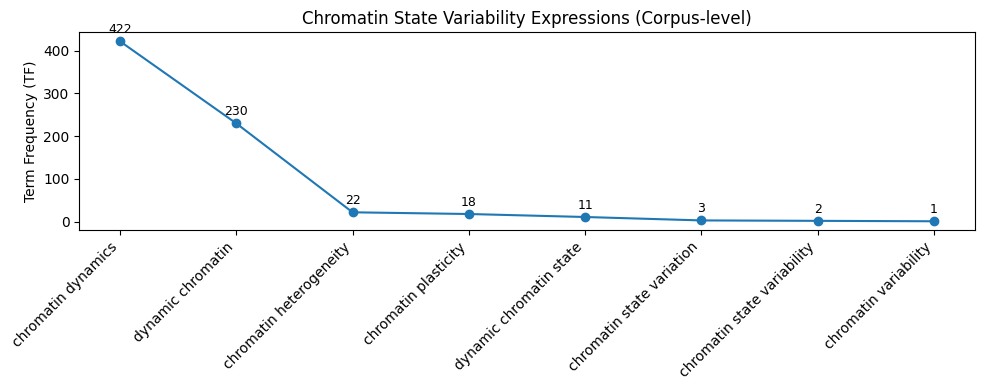

✅ Saved figure:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/Figure_chromatin_variability_TF_line_6152.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/Figure_chromatin_variability_TF_line_6152.pdf


In [ ]:
# 0) Google Drive 마운트 (Colab에서 Drive 접근)
from google.colab import drive
drive.mount('/content/drive')

import os
import re
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) 경로 설정
# =========================
# CORPUS_DIR: .txt full-text 파일들이 들어있는 폴더
# OUT_DIR: 결과 CSV/TXT/그림 저장 폴더
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"
OUT_DIR = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126"
os.makedirs(OUT_DIR, exist_ok=True)  # 폴더가 없으면 생성

# =========================
# 2) Chromatin variability 관련 표현(패턴) 목록
# =========================
# 분석 대상으로 삼을 "문구/표현" 리스트
# (문자열 매칭 기반: 정확히 이 문자열이 문서에 포함되면 카운트됨)
chromatin_variability_patterns = [
    "chromatin variability",
    "chromatin heterogeneity",
    "chromatin dynamics",
    "dynamic chromatin",
    "chromatin plasticity",
    "chromatin state variation",
    "chromatin state variability",
    "dynamic chromatin state"
]

# 컨텍스트(문장) 샘플 저장 제한
MAX_CONTEXT_PER_PATTERN = 5          # 패턴별로 전체 코퍼스에서 최대 몇 문장까지 저장할지
MAX_CONTEXT_PER_DOC_PER_PATTERN = 3  # 문서 1개에서 패턴별 최대 몇 문장까지 저장할지

# 필터링 키워드(현재는 전체 분석: []이면 필터 없음)
additional_keywords = []

# =========================
# 3) 전처리함수
# =========================
def normalize_text(text: str) -> str:
    """텍스트를 소문자로 만들고 공백을 정리해서 검색/카운트가 일관되게 되도록 함"""
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text

def split_sentences(text: str):
    """문장 분리: ., !, ? 뒤 공백 기준으로 문장을 나눔"""
    return re.split(r"(?<=[.!?])\s+", text)

def count_keyword(text_norm: str, keyword: str) -> int:
    """정규화된 텍스트에서 keyword(문자열)의 등장 횟수(TF)를 계산"""
    return len(re.findall(re.escape(keyword.lower()), text_norm))

def load_txt_files_from_folder(folder_path: str):
    """폴더 내 .txt 파일을 모두 읽어서 (파일명, 텍스트) 리스트로 반환"""
    docs = []
    for fn in sorted(os.listdir(folder_path)):
        if fn.lower().endswith(".txt"):
            fp = os.path.join(folder_path, fn)
            with open(fp, "r", encoding="utf-8", errors="ignore") as f:
                docs.append((fn, f.read()))
    return docs

def extract_variability_from_doc(doc_text: str):
    """문서 1개에서 패턴별 TF와 패턴이 포함된 문장(컨텍스트) 추출"""
    text_norm = normalize_text(doc_text)
    sentences = split_sentences(text_norm)

    tf = Counter()                 # 문서 내 패턴별 TF(언급 횟수)
    contexts = defaultdict(list)   # 문서 내 패턴별 컨텍스트 문장 리스트

    for p in chromatin_variability_patterns:
        # 문서 전체에서 p가 몇 번 등장했는지 카운트
        tf[p] = count_keyword(text_norm, p)

        # 한 번이라도 등장하면, 포함된 문장을 최대 MAX_CONTEXT_PER_DOC_PER_PATTERN개까지 수집
        if tf[p] > 0:
            for s in sentences:
                if p.lower() in s:
                    if len(contexts[p]) < MAX_CONTEXT_PER_DOC_PER_PATTERN:
                        contexts[p].append(s.strip())

    return tf, contexts

# =========================
# 4) 코퍼스 로드
# =========================
docs = load_txt_files_from_folder(CORPUS_DIR)
print(f"Found .txt files: {len(docs)}")

# =========================
# 5) 전체 코퍼스에서 TF/DF 및 컨텍스트 샘플 누적
# =========================
tf_total = Counter()                 # 코퍼스 전체 패턴별 TF 총합
df_docs = Counter()                  # 코퍼스 전체 패턴별 DF(등장 문서 수)
context_samples = defaultdict(list)  # 코퍼스 전체 패턴별 컨텍스트 샘플(최대 MAX_CONTEXT_PER_PATTERN)

analyzed_docs = 0

for filename, text in docs:
    analyzed_docs += 1

    # 문서 1개에서 패턴별 TF, 컨텍스트 추출
    tf_doc, ctx_doc = extract_variability_from_doc(text)

    # 코퍼스 TF 누적 (문서별 TF를 모두 더함)
    tf_total.update(tf_doc)

    # DF 누적: 문서에서 p가 1번이라도 나오면 df_docs[p] += 1
    for p in chromatin_variability_patterns:
        if tf_doc[p] > 0:
            df_docs[p] += 1

    # 코퍼스 컨텍스트 샘플 누적: 패턴별로 최대 MAX_CONTEXT_PER_PATTERN개까지 저장
    for p, sents in ctx_doc.items():
        for s in sents:
            if len(context_samples[p]) < MAX_CONTEXT_PER_PATTERN:
                context_samples[p].append(f"[{filename}] {s}")

print(f"Analyzed docs: {analyzed_docs}")

# =========================
# 6) 결과 저장 (CSV 요약 + TXT 컨텍스트)
# =========================
# summary:
# - DF_documents_containing_expression: 해당 표현이 등장한 문서 수(DF)
# - TF_total_mentions: 코퍼스 전체에서 해당 표현의 총 등장 횟수(TF)
summary = pd.DataFrame({
    "DF_documents_containing_expression": pd.Series(df_docs),
    "TF_total_mentions": pd.Series(tf_total)
}).fillna(0).astype(int).sort_values(
    "TF_total_mentions", ascending=False
)

# 저장 경로
summary_csv = os.path.join(
    OUT_DIR, "chromatin_variability_expression_summary_6152.csv"
)
context_txt = os.path.join(
    OUT_DIR, "chromatin_variability_context_samples_6152.txt"
)

# CSV 저장
summary.to_csv(summary_csv, encoding="utf-8-sig")

# 컨텍스트 샘플 TXT 저장
with open(context_txt, "w", encoding="utf-8") as f:
    for p in chromatin_variability_patterns:
        f.write(f"\n=== {p} ===\n")
        for s in context_samples.get(p, []):
            f.write(s + "\n")

print("Saved outputs:")
print(" -", summary_csv)
print(" -", context_txt)

# =========================
# 7) (옵션) TF 선그래프(Line plot) 생성
# =========================
plt.figure(figsize=(10,4))

# 정렬된 summary 기준으로 TF 값 시리즈 추출
tf_series = summary["TF_total_mentions"]
x_labels = list(tf_series.index)   # x축 라벨: 패턴(표현) 문자열들
y_vals = list(tf_series.values)    # y축 값: 패턴별 TF

x = list(range(len(x_labels)))
plt.plot(x, y_vals, marker="o")
plt.xticks(x, x_labels, rotation=45, ha="right")
plt.ylabel("Term Frequency (TF)")
plt.title("Chromatin State Variability Expressions (Corpus-level)")

# 라벨 표시를 위한 기본 offset (최대값의 3% 또는 최소 1)
y_max = max(y_vals) if len(y_vals) > 0 else 1
offset = max(1, int(y_max * 0.03))

# 각 점 위에 TF 값을 텍스트로 표시
for i, val in enumerate(y_vals):
    plt.text(i, val + offset, str(val),
             ha="center", va="bottom", fontsize=9)

plt.tight_layout()

# 그림 저장 경로 (PNG 600dpi + PDF)
fig_png = os.path.join(
    OUT_DIR, "Figure_chromatin_variability_TF_line_6152.png"
)
fig_pdf = os.path.join(
    OUT_DIR, "Figure_chromatin_variability_TF_line_6152.pdf"
)

plt.savefig(fig_png, dpi=600)
plt.savefig(fig_pdf)
plt.show()

print("Saved figure:")
print(" -", fig_png)
print(" -", fig_pdf)

**3. Gene–Epigenetic Relationship Extraction(gene ↔ epigenetic mark)**

In [ ]:
!pip -q install spacy
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 33.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# =========================
# Google Drive 마운트 (Colab에서 Drive 접근)
# =========================
from google.colab import drive
drive.mount('/content/drive')

import os
import spacy
import pandas as pd

# =========================
# 1) 경로 설정
# =========================
# CORPUS_DIR: 분석할 .txt 문서들이 있는 폴더 (문서 1개 = 파일 1개)
# OUT_DIR: 결과 CSV를 저장할 폴더
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"
OUT_DIR = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126"
os.makedirs(OUT_DIR, exist_ok=True)  # 출력 폴더가 없으면 생성

# =========================
# 2) spaCy 모델 로드
# =========================
# en_core_web_sm: 영어 기본 모델
# - doc.sents(문장 분리)와 ent(개체 인식, NER)을 위해 사용
nlp = spacy.load("en_core_web_sm")  # sentence parsing 필요

# =========================
# 3) 키워드 정의 (축소 세트)
# =========================
# epigenetic_keywords:
# - 문서/문장에서 찾고 싶은 후성유전 관련 키워드
# - 모두 소문자로 비교하기 위해 lower 버전도 생성
epigenetic_keywords = [
    "dna methylation",
    "methylation",
    "hypermethylation",
    "hypomethylation",
    "histone modification",
    "gene silencing",
    "dnmt"
]
epikws_lower = [k.lower() for k in epigenetic_keywords]

# 문서 1개당 최대 몇 문장을 추출할지 (필터 통과한 문장 중에서)
MAX_SENTENCES_PER_DOC = 5

# 진행률 출력 주기 (문서 i 처리할 때마다 출력)
PROGRESS_EVERY = 100

# 너무 긴 문서는 spaCy가 느려지므로 앞부분만 자르는 옵션
# (None으로 두면 자르지 않음)
MAX_CHARS = 200_000

# =========================
# 4) 코퍼스 파일 리스트 로드
# =========================
# 폴더 내 .txt 파일만 모아서 정렬
files = [fn for fn in sorted(os.listdir(CORPUS_DIR)) if fn.lower().endswith(".txt")]
print("Found documents:", len(files))  # 전체 txt 문서 개수

# =========================
# 5) 사전 필터링 (spaCy 처리 전에 문자열 검색으로 빠르게 걸러냄)
# =========================
# texts: spaCy에 넣을 문서 텍스트 리스트(필터 통과한 문서만)
# kept_files: texts와 1:1로 매칭되는 파일명 리스트
texts = []
kept_files = []

for fn in files:
    fp = os.path.join(CORPUS_DIR, fn)
    with open(fp, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()

    text_lower = text.lower()

    # 문서 전체에서 epigenetic 키워드가 하나도 없으면 분석 대상에서 제외
    if not any(k in text_lower for k in epikws_lower):
        continue

    # 문서가 너무 길면 앞부분만 잘라서 처리 (속도/메모리 안정화 목적)
    if MAX_CHARS is not None and len(text) > MAX_CHARS:
        text = text[:MAX_CHARS]

    kept_files.append(fn)
    texts.append(text)

print("Docs after pre-filter:", len(texts))  # spaCy에 실제로 들어갈 문서 수

# =========================
# 6) 문장 추출 (spaCy pipe로 배치 처리 + 진행률 출력)
# =========================
results = []
total_docs = len(texts)

# nlp.pipe:
# - 여러 문서를 배치로 처리하여 속도 향상
# - batch_size=8: 한 번에 8개 문서를 묶어서 처리
for i, doc in enumerate(nlp.pipe(texts, batch_size=8), 1):

    # 진행률 출력 (처리 속도에 큰 영향 없이 상태 확인 가능)
    if i % PROGRESS_EVERY == 0 or i == 1 or i == total_docs:
        print(f"Processed {i}/{total_docs} filtered docs...")

    filename = kept_files[i - 1]
    extracted = 0  # 해당 문서에서 몇 문장을 추출했는지 카운트

    # 문서의 문장 단위로 순회
    for sent in doc.sents:
        # 문서당 최대 추출 문장 수를 넘으면 중단
        if extracted >= MAX_SENTENCES_PER_DOC:
            break

        sent_text = sent.text.strip()
        sent_lower = sent_text.lower()

        # 문장에 epigenetic 키워드가 없으면 제외
        if not any(k in sent_lower for k in epikws_lower):
            continue

        # 개체 인식(NER) 결과에서 특정 라벨만 추출
        # 주석에도 적었지만: gene-like entity를 엄밀히 잡는 목적이라기보다는
        # "문장에 등장한 이름/기관/지명 등"을 넓게 잡기 위한 설정
        entities = [
            ent.text for ent in sent.ents
            if ent.label_ in ["ORG", "PRODUCT", "PERSON", "NORP", "GPE"]
        ]

        # 엔티티가 하나라도 있으면 결과로 저장
        if entities:
            results.append({
                "file": filename,  # 어떤 문서에서 나온 문장인지
                "entities_mentioned": "; ".join(sorted(set(entities))),  # 중복 제거 후 정렬
                "sentence": sent_text  # 키워드 포함 문장 원문
            })
            extracted += 1  # 문서 내 추출 문장 수 증가

print("Extraction finished.")
print("Total extracted sentences:", len(results))  # 전체 결과 행 개수

# =========================
# 7) 결과 저장 (CSV)
# =========================
out_csv = os.path.join(
    OUT_DIR, "gene_epigenetic_relation_sentences_6152.csv"
)

pd.DataFrame(results).to_csv(out_csv, index=False, encoding="utf-8-sig")

print("Saved output:")
print(" -", out_csv)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found documents: 6152
Docs after pre-filter: 3437
Processed 1/3437 filtered docs...
Processed 100/3437 filtered docs...
Processed 200/3437 filtered docs...
Processed 300/3437 filtered docs...
Processed 400/3437 filtered docs...
Processed 500/3437 filtered docs...
Processed 600/3437 filtered docs...
Processed 700/3437 filtered docs...
Processed 800/3437 filtered docs...
Processed 900/3437 filtered docs...
Processed 1000/3437 filtered docs...
Processed 1100/3437 filtered docs...
Processed 1200/3437 filtered docs...
Processed 1300/3437 filtered docs...
Processed 1400/3437 filtered docs...
Processed 1500/3437 filtered docs...
Processed 1600/3437 filtered docs...
Processed 1700/3437 filtered docs...
Processed 1800/3437 filtered docs...
Processed 1900/3437 filtered docs...
Processed 2000/3437 filtered docs...
Processed 2100/3437 filtered docs...
Processed 2200/3437

**GeneLike_PostProcessing_Epigenomics**

CSV(gene_epigenetic_relation_sentences_6152.csv)를 기반으로 “gene 패턴 정규식 필터링 + Top gene-like 목록 + 표/그림

Mounted at /content/drive
Loaded rows: 12160
Rows with gene-like + epigenetic keyword: 8648
Unique gene-like tokens: 8401
Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/gene_like_epigenetic_sentences_filtered.csv
Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/top_gene_like_frequency_top30.csv
Saved: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/gene_x_epigenetic_keyword_cooc_top20.csv


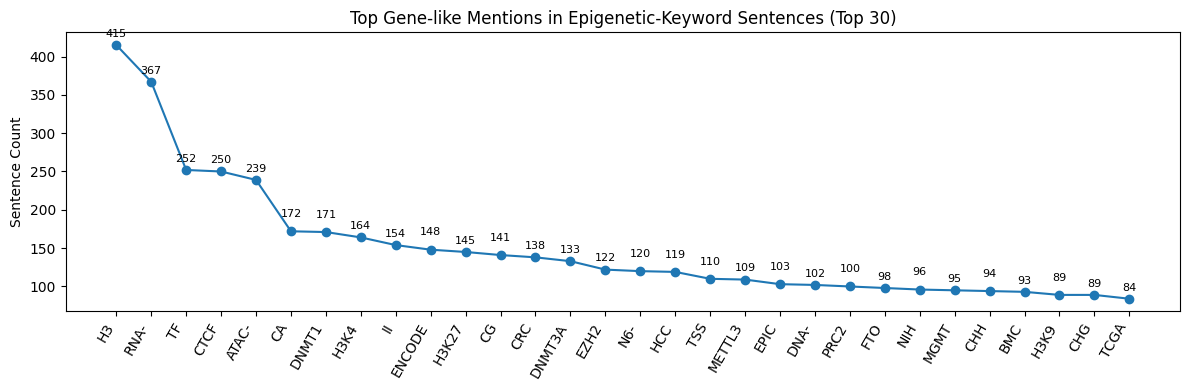

Saved Figure 1:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/Figure1_top_gene_like_line_top30.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/Figure1_top_gene_like_line_top30.pdf


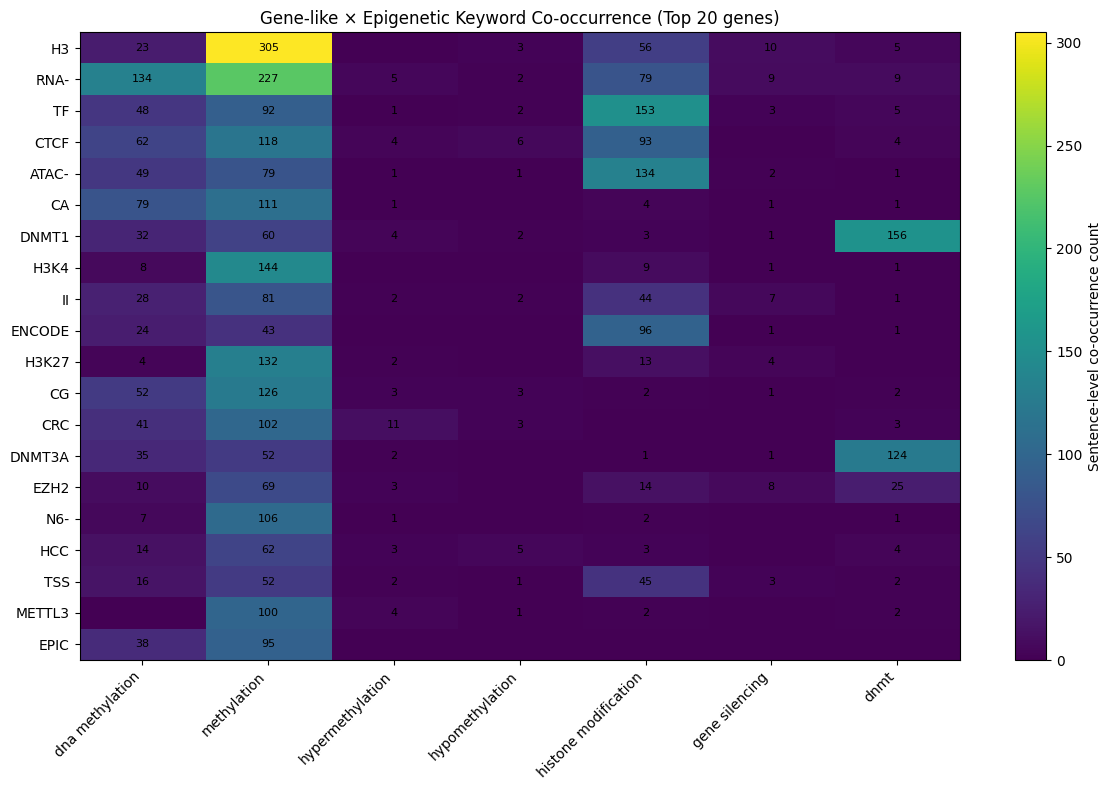

Saved Figure 2:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/Figure2_gene_x_epigenetic_heatmap_top20.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/Figure2_gene_x_epigenetic_heatmap_top20.pdf

 Done.
Outputs:
 - Filtered sentences: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/gene_like_epigenetic_sentences_filtered.csv
 - Top gene table: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/top_gene_like_frequency_top30.csv
 - Co-occurrence matrix: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/gene_x_epigenetic_keyword_cooc_top20.csv


In [ ]:
# =========================
# Google Drive 마운트 (Colab에서 Drive 접근)
# =========================
from google.colab import drive
drive.mount('/content/drive')

import os
import re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) 경로 설정
# =========================
# OUT_DIR: 입력 CSV가 있는 폴더이자, 결과물(CSV/그림) 저장 폴더
OUT_DIR = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126"
os.makedirs(OUT_DIR, exist_ok=True)

# 입력 파일: 이전 단계에서 생성된 문장 추출 CSV
IN_CSV = os.path.join(OUT_DIR, "gene_epigenetic_relation_sentences_6152.csv")

# =========================
# 2) CSV 로드
# =========================
df = pd.read_csv(IN_CSV, encoding="utf-8")

# sentence 컬럼이 반드시 있어야 함 (이 문장을 대상으로 gene-like와 키워드 매칭 수행)
assert "sentence" in df.columns, "CSV must have a 'sentence' column"

print("Loaded rows:", len(df))  # 입력 CSV 전체 행 수

# =========================
# 3) Epigenetic 키워드 목록 (이전 단계와 동일 세트)
# =========================
epigenetic_keywords = [
    "dna methylation",
    "methylation",
    "hypermethylation",
    "hypomethylation",
    "histone modification",
    "gene silencing",
    "dnmt"
]
# 소문자 비교를 위한 lower 버전
epikws_lower = [k.lower() for k in epigenetic_keywords]

# 문장(sent)에서 포함된 epigenetic 키워드 목록을 반환하는 함수
def matched_epikws(sent: str):
    s = sent.lower()
    return [k for k in epikws_lower if k in s]

# =========================
# 4) Gene-like 정규표현식 정의
# =========================
# Gene-like 휴리스틱 패턴(바이오 텍스트에서 흔한 gene symbol 형태를 대략적으로 포착):
# - 대문자로 시작
# - 대문자/숫자/하이픈 조합
# - 길이 2~15
# 예: TP53, BRCA1, DNMT1, EZH2, H3K27, IL-6
GENE_REGEX = re.compile(r"\b[A-Z][A-Z0-9\-]{1,14}\b")

# Stoplist:
# - 유전자처럼 보이지만 실제로는 흔한 약어/섹션명/기관명 등인 토큰을 제거하여 오탐 감소
STOP_TOKENS = set([
    "DNA", "RNA", "MRNA", "CDNA", "PCR", "NGS", "WGBS", "RRBS",
    "ATAC", "ATACSEQ", "ATAC-SEQ", "CHIP", "CHIPSEQ", "CHIP-SEQ",
    "HIC", "HI-C", "FAIRE", "DNASE", "DNASESEQ", "DNASE-SEQ",
    "RIP", "RIPSEQ", "RIP-SEQ", "CLIP", "CLIPSEQ", "CLIP-SEQ",
    "CNS", "USA", "UK", "EU", "COVID", "SARS", "WHO", "FDA",
    "FIG", "TABLE", "SUPPLEMENTARY", "METHODS", "RESULTS"
])

def extract_gene_like_tokens(sent: str):
    """
    문장(sent)에서 gene-like 토큰을 regex로 추출한 뒤,
    stoplist 및 일부 예외 규칙으로 정제(cleaning)하여 반환.
    """
    tokens = GENE_REGEX.findall(sent)

    cleaned = []
    for t in tokens:
        t2 = t.strip()

        # stoplist에 있으면 제거
        if t2 in STOP_TOKENS:
            continue

        # '-SEQ', 'SEQ'로 끝나는 토큰은 assay 관련 약어일 가능성이 높아 제거
        if t2.endswith("SEQ") or t2.endswith("-SEQ"):
            continue

        cleaned.append(t2)

    return cleaned

# =========================
# 5) 행 단위(row-level) 필터링 및 추출
# =========================
# 목표:
# - sentence에서 (gene-like 토큰이 1개 이상) AND (epigenetic 키워드가 1개 이상) 인 행만 남김
rows = []
gene_counter = Counter()  # gene-like 토큰 빈도(문장 단위 등장 횟수) 집계

for _, r in df.iterrows():
    sent = str(r["sentence"])

    # 문장에서 gene-like 토큰 추출
    genes = extract_gene_like_tokens(sent)
    if not genes:
        continue  # gene-like가 없으면 제외

    # 문장에서 epigenetic 키워드 매칭
    kws = matched_epikws(sent)
    if not kws:
        continue  # 키워드가 없으면 제외

    # gene-like 빈도 업데이트
    # 주의: 여기서는 genes 리스트(문장 내 등장 토큰들)를 그대로 업데이트하므로
    # 같은 문장에 같은 토큰이 여러 번 있으면 그만큼 증가할 수 있음(텍스트에 따라 다름).
    gene_counter.update(genes)

    # 필터된 행 저장
    rows.append({
        "file": r.get("file", ""),  # 파일명(없을 수도 있어 get 사용)
        "genes": "; ".join(sorted(set(genes))),  # 문장 내 gene-like 토큰들(중복 제거)
        "epigenetic_keywords_matched": "; ".join(sorted(set(kws))),  # 문장 내 매칭된 키워드(중복 제거)
        "sentence": sent
    })

# 필터 결과 데이터프레임 생성
df_gene = pd.DataFrame(rows)
print("Rows with gene-like + epigenetic keyword:", len(df_gene))  # 필터 통과 문장 수
print("Unique gene-like tokens:", len(gene_counter))            # 고유 gene-like 토큰 수

# 필터된 문장 CSV 저장
filtered_csv = os.path.join(OUT_DIR, "gene_like_epigenetic_sentences_filtered.csv")
df_gene.to_csv(filtered_csv, index=False, encoding="utf-8-sig")
print("Saved:", filtered_csv)

# =========================
# 6) Top gene-like 빈도 테이블 생성
# =========================
TOP_N_GENES = 30  # 상위 몇 개 gene-like 토큰을 볼지
top_genes = gene_counter.most_common(TOP_N_GENES)

# top_gene_df:
# - gene_like: gene-like 토큰
# - sentence_count: (문장 기반) 해당 토큰이 등장한 횟수
top_gene_df = pd.DataFrame(top_genes, columns=["gene_like", "sentence_count"])

top_gene_csv = os.path.join(OUT_DIR, f"top_gene_like_frequency_top{TOP_N_GENES}.csv")
top_gene_df.to_csv(top_gene_csv, index=False, encoding="utf-8-sig")
print("Saved:", top_gene_csv)

# =========================
# 7) Gene × Keyword 동시출현(co-occurrence) 행렬 생성 (문장 단위)
# =========================
TOP_K_GENES_FOR_HEATMAP = 20  # 히트맵에는 상위 몇 개 gene-like를 쓸지
top_gene_list = [g for g, _ in gene_counter.most_common(TOP_K_GENES_FOR_HEATMAP)]

# 행: top gene-like, 열: epigenetic_keywords(원형 표기)
# 값: 같은 문장에서 (gene g)와 (keyword k)가 함께 등장한 문장 수
cooc = pd.DataFrame(0, index=top_gene_list, columns=epigenetic_keywords)

# 필터된 문장(df_gene)을 기반으로 행렬 채우기
for _, r in df_gene.iterrows():
    sent = r["sentence"]

    # 문장에 포함된 키워드 목록(lower 기준)
    kws = matched_epikws(sent)

    # 문장에서 gene-like 토큰 재추출(정규표현식 기반)
    genes = extract_gene_like_tokens(sent)

    # 히트맵 대상 상위 gene만 남김
    genes = [g for g in genes if g in top_gene_list]
    if not genes:
        continue

    # cooc 증가:
    # - 같은 문장에서 gene와 keyword가 함께 등장하면 +1
    # - 중복 증가 방지를 위해 set() 사용(해당 문장에 여러 번 나와도 1문장=1로 집계)
    for g in set(genes):
        for k in set(kws):
            # k(lower) 값을 epigenetic_keywords의 canonical 라벨로 매핑
            for canon in epigenetic_keywords:
                if canon.lower() == k:
                    cooc.loc[g, canon] += 1

# cooc 행렬 CSV 저장
cooc_csv = os.path.join(OUT_DIR, f"gene_x_epigenetic_keyword_cooc_top{TOP_K_GENES_FOR_HEATMAP}.csv")
cooc.to_csv(cooc_csv, encoding="utf-8-sig")
print("Saved:", cooc_csv)

# =========================
# 8) Figure 1 — Top genes 선그래프 + 값 라벨(겹침 완화)
# =========================
plt.figure(figsize=(12, 4))

x_labels = top_gene_df["gene_like"].tolist()          # x축 라벨: gene-like 토큰
y_vals = top_gene_df["sentence_count"].tolist()       # y축 값: 등장 횟수
x = list(range(len(x_labels)))

plt.plot(x, y_vals, marker="o")
plt.xticks(x, x_labels, rotation=60, ha="right")
plt.ylabel("Sentence Count")
plt.title(f"Top Gene-like Mentions in Epigenetic-Keyword Sentences (Top {TOP_N_GENES})")

# 라벨 겹침 완화를 위한 offset 설정
y_max = max(y_vals) if y_vals else 1
base_offset = max(1, int(y_max * 0.02))    # 최대값의 2% 또는 최소 1
close_thresh = max(1, int(y_max * 0.015))  # 이 값 이내로 이웃과 가까우면 더 띄움

for i, val in enumerate(y_vals):
    dy = base_offset

    # 이웃 점과 값이 너무 가까우면 라벨 위치를 번갈아 더 띄우는 방식
    if i > 0 and abs(val - y_vals[i-1]) <= close_thresh:
        dy = base_offset * (2 if i % 2 == 0 else 1)
    if i < len(y_vals)-1 and abs(val - y_vals[i+1]) <= close_thresh:
        dy = base_offset * (2 if i % 2 == 1 else 1)

    # 점 위에 수치(등장 횟수) 표기
    plt.text(i, val + dy, str(val), ha="center", va="bottom", fontsize=8)

plt.tight_layout()

# 그림 저장(논문용 600dpi PNG + PDF)
fig1_png = os.path.join(OUT_DIR, f"Figure1_top_gene_like_line_top{TOP_N_GENES}.png")
fig1_pdf = os.path.join(OUT_DIR, f"Figure1_top_gene_like_line_top{TOP_N_GENES}.pdf")
plt.savefig(fig1_png, dpi=600)
plt.savefig(fig1_pdf)
plt.show()

print("Saved Figure 1:")
print(" -", fig1_png)
print(" -", fig1_pdf)

# =========================
# 9) Figure 2 — 히트맵 + 셀 내부 값 라벨
# =========================
plt.figure(figsize=(12, 8))

# cooc 행렬을 이미지로 표현
# (행: gene-like, 열: epigenetic keyword, 값: 문장 단위 동시출현 횟수)
im = plt.imshow(cooc.values, aspect="auto")

plt.xticks(range(len(cooc.columns)), cooc.columns, rotation=45, ha="right")
plt.yticks(range(len(cooc.index)), cooc.index)
plt.colorbar(im, label="Sentence-level co-occurrence count")
plt.title(f"Gene-like × Epigenetic Keyword Co-occurrence (Top {TOP_K_GENES_FOR_HEATMAP} genes)")

# 셀 내부 값 주석(0은 생략, threshold 이상만 표시)
threshold = 1
for i in range(cooc.shape[0]):
    for j in range(cooc.shape[1]):
        val = int(cooc.iat[i, j])
        if val >= threshold:
            plt.text(j, i, str(val), ha="center", va="center", fontsize=8)

plt.tight_layout()

# 그림 저장(논문용 600dpi PNG + PDF)
fig2_png = os.path.join(OUT_DIR, f"Figure2_gene_x_epigenetic_heatmap_top{TOP_K_GENES_FOR_HEATMAP}.png")
fig2_pdf = os.path.join(OUT_DIR, f"Figure2_gene_x_epigenetic_heatmap_top{TOP_K_GENES_FOR_HEATMAP}.pdf")
plt.savefig(fig2_png, dpi=600)
plt.savefig(fig2_pdf)
plt.show()

print("Saved Figure 2:")
print(" -", fig2_png)
print(" -", fig2_pdf)

print("\n Done.")
print("Outputs:")
print(" - Filtered sentences:", filtered_csv)
print(" - Top gene table:", top_gene_csv)
print(" - Co-occurrence matrix:", cooc_csv)

**4. Cell-type Specific Epigenetics**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found .txt files: 6152
Analyzed docs: 6152
Skipped docs: 0
Saved outputs:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/celltype_frequency_summary_6152.csv
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/celltype_x_methylation_cooc_6152.csv
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/celltype_x_assay_cooc_6152.csv
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/celltype_context_samples_6152.txt


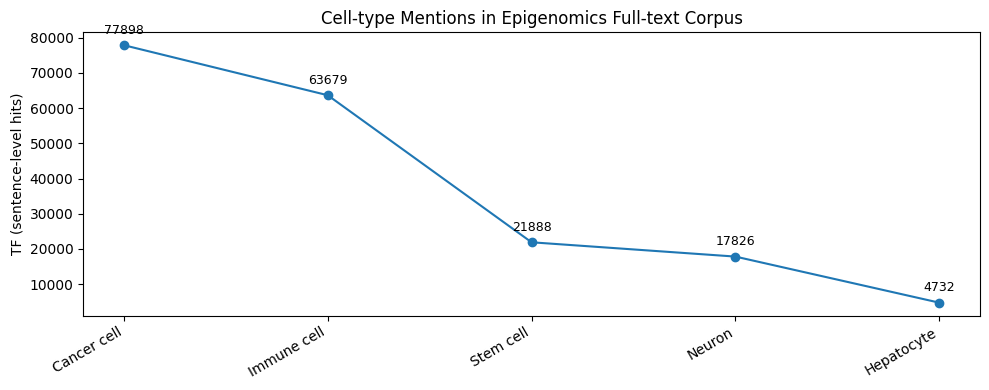

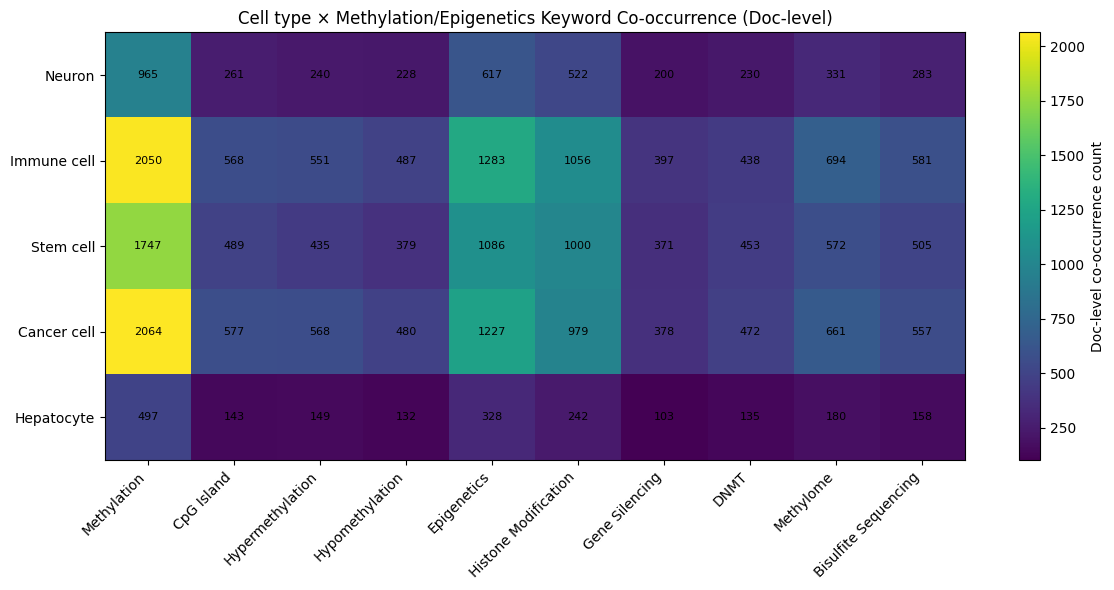

Saved figures:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/Figure_celltype_TF_line_6152.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/Figure_celltype_TF_line_6152.pdf
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/Figure_celltype_x_methylation_heatmap_annot_6152.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/Figure_celltype_x_methylation_heatmap_annot_6152.pdf


In [ ]:
# =========================
# Google Drive 마운트 (Colab에서 Drive 접근)
# =========================
from google.colab import drive
drive.mount('/content/drive')

import os
import re
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) 경로 설정
# =========================
# CORPUS_DIR: 분석할 full-text(.txt) 파일 폴더
# OUT_DIR: 결과 CSV/TXT/그림 저장 폴더
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"
OUT_DIR = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# 2) 키워드
# =========================
# assay_keywords: 실험/분석 기법(assay) 키워드
assay_keywords = [
    "5C", "ChIA-PET", "Hi-C", "DNase-seq", "FAIRE-seq", "ATAC-seq", "ChIP-seq",
    "WGBS", "RRBS", "methylation array", "Computational", "predictions",
    "RNA-seq", "CLIP-seq", "RIP-seq", "Histone Modification"
]

# methylation_keywords: methylation/epigenetics 관련 개념 키워드
methylation_keywords = [
    "Methylation", "CpG Island", "Hypermethylation", "Hypomethylation",
    "Epigenetics", "Histone Modification", "Gene Silencing", "DNMT",
    "Methylome", "Bisulfite Sequencing"
]

# additional_keywords:
# - 문서 필터링용(현재는 []로 전체 분석)
additional_keywords = []

# =========================
# 3) Cell type 사전(확장형 regex 패턴)
# =========================
# - Full text에서 흔히 등장하는 변형(복수형, 형용사형 등)을 regex로 포괄
# - 예: neuron(s), neuronal / tumor/tumour 등
cell_type_patterns = {
    "Neuron": r"\bneuron(s)?\b|\bneuronal\b",
    "Immune cell": r"\bimmune cell(s)?\b|\bimmune\b|\blymphocyte(s)?\b|\bt cell(s)?\b|\bb cell(s)?\b|\bmacrophage(s)?\b",
    "Stem cell": r"\bstem cell(s)?\b|\bpluripotent\b|\biPSC\b|\bprogenitor cell(s)?\b",
    "Cancer cell": r"\bcancer cell(s)?\b|\btumou?r cell(s)?\b|\bmalignan(t|cy)\b|\bcarcinoma\b|\btumou?r\b",
    "Hepatocyte": r"\bhepatocyte(s)?\b|\bhepatic\b|\bliver cell(s)?\b"
}

# 셀타입 목록(행렬 인덱스로 사용)
CELL_TYPES = list(cell_type_patterns.keys())

# 컨텍스트 문장 샘플 저장 제한
MAX_CONTEXT_PER_CELL = 5          # 셀타입별 전체 코퍼스에서 최대 샘플 문장 수
MAX_CONTEXT_PER_DOC_PER_CELL = 2  # 문서 1개에서 셀타입별 최대 샘플 문장 수

# =========================
# 4) 전처리 함수
# =========================
def normalize_text(t: str) -> str:
    """소문자 처리 + 공백 정리(정규화)"""
    t = t.lower()
    t = re.sub(r"\s+", " ", t)
    return t

def split_sentences(text: str):
    """문장 분리(간단 규칙): . ! ? 뒤 공백 기준"""
    return re.split(r"(?<=[.!?])\s+", text)

def load_txt_files_from_folder(folder_path: str):
    """폴더 내 .txt 파일을 모두 읽어 (파일명, 내용) 리스트로 반환"""
    files = []
    for fn in sorted(os.listdir(folder_path)):
        if fn.lower().endswith(".txt"):
            fp = os.path.join(folder_path, fn)
            with open(fp, "r", encoding="utf-8", errors="ignore") as f:
                files.append((fn, f.read()))
    return files

def passes_filter(text_norm: str, filters) -> bool:
    """additional_keywords가 비어있으면 True(필터 없음),
       비어있지 않으면 그 중 하나라도 문서에 포함될 때만 True"""
    if not filters:
        return True
    return any(f.lower() in text_norm for f in filters)

def doc_cell_types(text_norm: str):
    """문서 전체(text_norm)에서 각 cell type regex가 매칭되면 해당 cell type을 present로 판정"""
    found = []
    for ct, pat in cell_type_patterns.items():
        if re.search(pat, text_norm, re.IGNORECASE):
            found.append(ct)
    return found

# =========================
# 5) 코퍼스 로드
# =========================
docs = load_txt_files_from_folder(CORPUS_DIR)
print(f"Found .txt files: {len(docs)}")

# =========================
# 6) 핵심 추출
# =========================
cell_tf = Counter()          # cell type의 TF(문장 hit 수의 합; 근사치)
cell_df = Counter()          # cell type의 DF(등장 문서 수)
cell_context = defaultdict(list)  # cell type별 컨텍스트 문장 샘플 저장

# 문서 단위 동시출현(co-occurrence) 행렬
# - cooc_cell_x_meth[ct, mk] = ct와 mk가 같은 문서에 함께 등장한 문서 수
cooc_cell_x_meth = pd.DataFrame(0, index=CELL_TYPES, columns=methylation_keywords)

# 옵션: cell type × assay co-occurrence (문서 단위)
cooc_cell_x_assay = pd.DataFrame(0, index=CELL_TYPES, columns=assay_keywords)

analyzed_docs = 0
skipped_docs = 0

for filename, text in docs:
    doc_norm = normalize_text(text)

    # 필터 키워드가 있는 경우, 해당 키워드가 포함된 문서만 분석
    if not passes_filter(doc_norm, additional_keywords):
        skipped_docs += 1
        continue

    analyzed_docs += 1

    # 문장 분리(정규화된 텍스트 기준)
    sents = split_sentences(doc_norm)

    # 문서에 "존재"하는 cell type들(문서 단위 존재 여부)
    present_cells = doc_cell_types(doc_norm)

    # 문서에 "존재"하는 methylation 키워드들(문서 단위 존재 여부)
    present_meth  = [k for k in methylation_keywords if k.lower() in doc_norm]

    # 문서에 "존재"하는 assay 키워드들(문서 단위 존재 여부)
    present_assay = [a for a in assay_keywords if a.lower() in doc_norm]

    # DF 계산: 해당 cell type이 문서에 존재하면 +1
    for ct in present_cells:
        cell_df[ct] += 1

    # TF 근사치 계산:
    # - 해당 cell type이 문서에 존재한다고 판정된 경우에만
    # - 문장 단위로 regex가 hit 되는 횟수를 세어 TF에 누적
    # - 컨텍스트 문장도 같이 저장(문서당 최대 MAX_CONTEXT_PER_DOC_PER_CELL, 전체 최대 MAX_CONTEXT_PER_CELL)
    for ct in present_cells:
        pat = cell_type_patterns[ct]
        hit_count = 0
        per_doc_ctx = 0

        for s in sents:
            if re.search(pat, s, re.IGNORECASE):
                hit_count += 1

                # 컨텍스트 저장 제한 조건(문서별/전체)
                if per_doc_ctx < MAX_CONTEXT_PER_DOC_PER_CELL:
                    if len(cell_context[ct]) < MAX_CONTEXT_PER_CELL:
                        cell_context[ct].append(f"[{filename}] {s.strip()}")
                    per_doc_ctx += 1

        # 문서에서의 hit_count를 코퍼스 TF에 누적
        cell_tf[ct] += hit_count

    # 동시출현(co-occurrence): cell type × methylation (문서 단위 존재 기반)
    for ct in present_cells:
        for mk in present_meth:
            cooc_cell_x_meth.loc[ct, mk] += 1

    # 동시출현(co-occurrence): cell type × assay (문서 단위 존재 기반) [옵션]
    for ct in present_cells:
        for ak in present_assay:
            cooc_cell_x_assay.loc[ct, ak] += 1

print(f"Analyzed docs: {analyzed_docs}")
print(f"Skipped docs: {skipped_docs}")

# =========================
# 7) 표/컨텍스트 저장
# =========================
# summary:
# - DF_documents_containing_celltype: 해당 cell type이 등장한 문서 수(DF)
# - TF_sentence_hits_celltype: 문장 단위 regex hit 수의 총합(TF 근사치)
summary = pd.DataFrame({
    "DF_documents_containing_celltype": pd.Series(cell_df),
    "TF_sentence_hits_celltype": pd.Series(cell_tf)
}).fillna(0).astype(int).sort_values("TF_sentence_hits_celltype", ascending=False)

summary_path = os.path.join(OUT_DIR, "celltype_frequency_summary_6152.csv")
cooc_meth_path = os.path.join(OUT_DIR, "celltype_x_methylation_cooc_6152.csv")
cooc_assay_path = os.path.join(OUT_DIR, "celltype_x_assay_cooc_6152.csv")
ctx_path = os.path.join(OUT_DIR, "celltype_context_samples_6152.txt")

summary.to_csv(summary_path, encoding="utf-8-sig")
cooc_cell_x_meth.to_csv(cooc_meth_path, encoding="utf-8-sig")
cooc_cell_x_assay.to_csv(cooc_assay_path, encoding="utf-8-sig")

# 컨텍스트 샘플 TXT 저장
with open(ctx_path, "w", encoding="utf-8") as f:
    for ct in CELL_TYPES:
        f.write(f"\n=== {ct} ===\n")
        for s in cell_context.get(ct, []):
            f.write(s + "\n")

print("Saved outputs:")
print(" -", summary_path)
print(" -", cooc_meth_path)
print(" -", cooc_assay_path)
print(" -", ctx_path)

# =========================
# 8) Figure A: Cell-type TF 선그래프 + 값 라벨
# =========================
plt.figure(figsize=(10,4))

tf_series = summary["TF_sentence_hits_celltype"]
x_labels = tf_series.index.tolist()
y_vals = tf_series.values.tolist()
x = list(range(len(x_labels)))

plt.plot(x, y_vals, marker="o")
plt.xticks(x, x_labels, rotation=30, ha="right")
plt.ylabel("TF (sentence-level hits)")
plt.title("Cell-type Mentions in Epigenomics Full-text Corpus")

# 값 라벨 겹침 완화를 위한 offset 계산
y_max = max(y_vals) if y_vals else 1
base_offset = max(1, int(y_max * 0.03))
close_thresh = max(1, int(y_max * 0.02))

for i, val in enumerate(y_vals):
    dy = base_offset

    # 이웃 값과 너무 비슷하면 라벨 위치를 번갈아 띄워서 겹침 완화
    if i > 0 and abs(val - y_vals[i-1]) <= close_thresh:
        dy = base_offset * (2 if i % 2 == 0 else 1)
    if i < len(y_vals)-1 and abs(val - y_vals[i+1]) <= close_thresh:
        dy = base_offset * (2 if i % 2 == 1 else 1)

    plt.text(i, val + dy, str(val), ha="center", va="bottom", fontsize=9)

plt.tight_layout()

figA_png = os.path.join(OUT_DIR, "Figure_celltype_TF_line_6152.png")
figA_pdf = os.path.join(OUT_DIR, "Figure_celltype_TF_line_6152.pdf")
plt.savefig(figA_png, dpi=600)
plt.savefig(figA_pdf)
plt.show()

# =========================
# 9) Figure B: 히트맵 (Cell type × methylation keywords) + 셀 내부 값
# =========================
plt.figure(figsize=(12,6))

im = plt.imshow(cooc_cell_x_meth.values, aspect="auto")

plt.xticks(range(len(cooc_cell_x_meth.columns)), cooc_cell_x_meth.columns, rotation=45, ha="right")
plt.yticks(range(len(cooc_cell_x_meth.index)), cooc_cell_x_meth.index)
plt.colorbar(im, label="Doc-level co-occurrence count")
plt.title("Cell type × Methylation/Epigenetics Keyword Co-occurrence (Doc-level)")

# 셀 내부 값 표시 (0은 생략, threshold 이상만)
threshold = 1
for i in range(cooc_cell_x_meth.shape[0]):
    for j in range(cooc_cell_x_meth.shape[1]):
        val = int(cooc_cell_x_meth.iat[i, j])
        if val >= threshold:
            plt.text(j, i, str(val), ha="center", va="center", fontsize=8)

plt.tight_layout()

figB_png = os.path.join(OUT_DIR, "Figure_celltype_x_methylation_heatmap_annot_6152.png")
figB_pdf = os.path.join(OUT_DIR, "Figure_celltype_x_methylation_heatmap_annot_6152.pdf")
plt.savefig(figB_png, dpi=600)
plt.savefig(figB_pdf)
plt.show()

print("Saved figures:")
print(" -", figA_png)
print(" -", figA_pdf)
print(" -", figB_png)
print(" -", figB_pdf)

***5. Disease–Epigenetics Association Mining***

Mounted at /content/drive
Found .txt files: 6152
Analyzed docs: 6152
Skipped docs (additional filter): 0
Saved outputs:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/disease_frequency_summary_6152.csv
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/disease_x_methylation_cooc_6152.csv
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/disease_x_assay_cooc_6152.csv
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/disease_epigenetics_context_samples_6152.txt


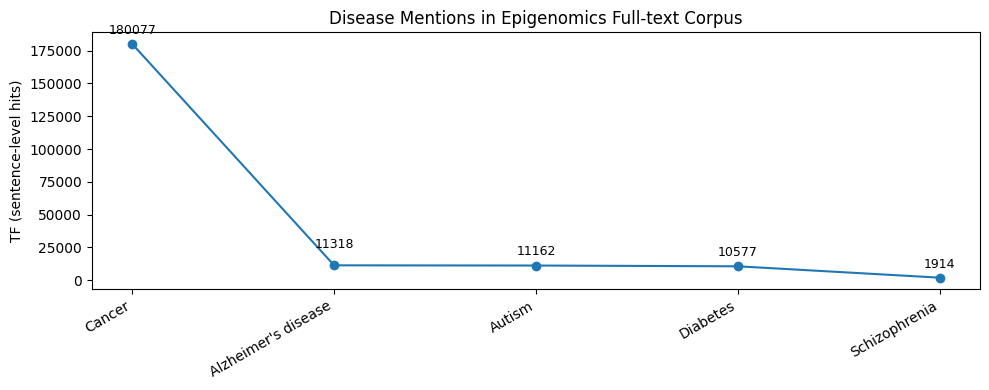

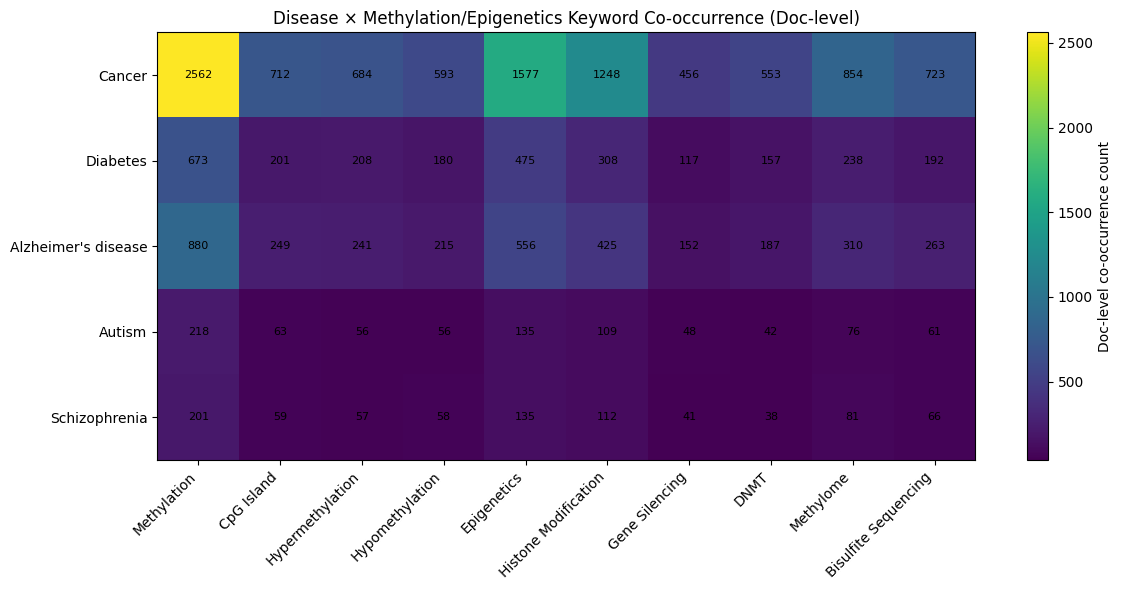

Saved figures:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/Figure_disease_TF_line_6152.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/Figure_disease_TF_line_6152.pdf
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/Figure_disease_x_methylation_heatmap_annot_6152.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/Figure_disease_x_methylation_heatmap_annot_6152.pdf


In [ ]:
# =========================
# Google Drive 마운트 (Colab에서 Drive 접근)
# =========================
from google.colab import drive
drive.mount('/content/drive')

import os
import re
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) 경로 설정
# =========================
# CORPUS_DIR: 분석할 full-text(.txt) 파일 폴더
# OUT_DIR: 결과 CSV/TXT/그림 저장 폴더
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"
OUT_DIR = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# 2) 키워드
# =========================
# assay_keywords: 실험/분석 기법(assay) 키워드
assay_keywords = [
    "5C", "ChIA-PET", "Hi-C", "DNase-seq", "FAIRE-seq", "ATAC-seq", "ChIP-seq",
    "WGBS", "RRBS", "methylation array", "Computational", "predictions",
    "RNA-seq", "CLIP-seq", "RIP-seq", "Histone Modification"
]

# methylation_keywords: methylation/epigenetics 관련 개념 키워드
methylation_keywords = [
    "Methylation", "CpG Island", "Hypermethylation", "Hypomethylation",
    "Epigenetics", "Histone Modification", "Gene Silencing", "DNMT",
    "Methylome", "Bisulfite Sequencing"
]

# additional_keywords:
# - 문서 필터링용(현재는 []로 전체 분석)
additional_keywords = []

# (선택) epigenetic 핵심 키워드
# - 문서를 "후성유전 관련 문서만" 제한하고 싶을 때 사용 가능
# - REQUIRE_EPI_CORE_IN_DOC=True로 두면 아래 has_epi_core()로 필터링됨
epi_core_keywords = ["epigenetic", "epigenetics", "methylation", "histone"]

# =========================
# 3) 질병 사전(확장형 regex 패턴)
# =========================
# - full-text에서 자주 등장하는 변형(복수형, 형용사형, 약어 등)을 regex로 포괄
# - tumou?r: tumor/tumour(미/영 표기 변형)
disease_patterns = {
    "Cancer": r"\bcancer(s)?\b|\btumou?r(s)?\b|\bcarcinoma(s)?\b|\bmalignan(t|cy)\b",
    "Diabetes": r"\bdiabetes\b|\bdiabetic\b|\bT1D\b|\bT2D\b",
    "Alzheimer's disease": r"\balzheimer('?s)?\b|\bAD\b|\balzheimer disease\b",
    "Autism": r"\bautism\b|\bASD\b|\bautism spectrum disorder\b",
    "Schizophrenia": r"\bschizophrenia\b|\bschizophrenic\b"
}

# 질병 목록(행렬 인덱스로 사용)
DISEASES = list(disease_patterns.keys())

# 컨텍스트 문장 샘플 저장 제한
MAX_CONTEXT_PER_DISEASE = 5          # 질병별 전체 코퍼스에서 최대 샘플 문장 수
MAX_CONTEXT_PER_DOC_PER_DISEASE = 2  # 문서 1개에서 질병별 최대 샘플 문장 수

# =========================
# 4) 전처리 함수들
# =========================
def normalize_text(t: str) -> str:
    """소문자 처리 + 공백 정리(정규화)"""
    t = t.lower()
    t = re.sub(r"\s+", " ", t)
    return t

def split_sentences(text: str):
    """문장 분리(간단 규칙): . ! ? 뒤 공백 기준"""
    return re.split(r"(?<=[.!?])\s+", text)

def load_txt_files_from_folder(folder_path: str):
    """폴더 내 .txt 파일을 모두 읽어 (파일명, 내용) 리스트로 반환"""
    files = []
    for fn in sorted(os.listdir(folder_path)):
        if fn.lower().endswith(".txt"):
            fp = os.path.join(folder_path, fn)
            with open(fp, "r", encoding="utf-8", errors="ignore") as f:
                files.append((fn, f.read()))
    return files

def passes_filter(text_norm: str, filters) -> bool:
    """additional_keywords가 비어있으면 True(필터 없음),
       비어있지 않으면 그 중 하나라도 문서에 포함될 때만 True"""
    if not filters:
        return True
    return any(f.lower() in text_norm for f in filters)

def doc_diseases(text_norm: str):
    """문서 전체(text_norm)에서 각 질병 regex가 매칭되면 해당 질병을 present로 판정"""
    found = []
    for d, pat in disease_patterns.items():
        if re.search(pat, text_norm, re.IGNORECASE):
            found.append(d)
    return found

def has_epi_core(text_norm: str):
    """(선택) epigenetic 핵심 키워드가 문서에 하나라도 있는지 확인"""
    return any(k in text_norm for k in epi_core_keywords)

# =========================
# 5) 코퍼스 로드
# =========================
docs = load_txt_files_from_folder(CORPUS_DIR)
print(f"Found .txt files: {len(docs)}")

# =========================
# 6) 핵심 추출
# =========================
disease_tf = Counter()           # 질병 TF(문장 hit 수 기반 근사치)
disease_df = Counter()           # 질병 DF(등장 문서 수)
disease_context = defaultdict(list)  # 질병별 컨텍스트 문장 샘플 저장

# 문서 단위 동시출현(co-occurrence) 행렬
# - cooc_dis_x_meth[disease, meth_kw] = 같은 문서에서 함께 등장한 문서 수
cooc_dis_x_meth = pd.DataFrame(0, index=DISEASES, columns=methylation_keywords)

# 옵션: 질병 × assay 동시출현(문서 단위)
cooc_dis_x_assay = pd.DataFrame(0, index=DISEASES, columns=assay_keywords)

analyzed_docs = 0
skipped_docs = 0
skipped_no_epi = 0  # (선택) epi-core 없는 문서를 제외할 경우 카운트

# 옵션:
# - "질병+epigenetic" 관계에 더 초점 맞추고 싶으면 True
REQUIRE_EPI_CORE_IN_DOC = False

for filename, text in docs:
    doc_norm = normalize_text(text)

    # 추가 필터(키워드 기반) 통과 못하면 제외
    if not passes_filter(doc_norm, additional_keywords):
        skipped_docs += 1
        continue

    # 옵션: 후성유전 핵심 키워드가 없는 문서 제외
    if REQUIRE_EPI_CORE_IN_DOC and not has_epi_core(doc_norm):
        skipped_no_epi += 1
        continue

    analyzed_docs += 1
    sents = split_sentences(doc_norm)

    # 문서에 등장하는 질병 목록(문서 단위 존재)
    present_diseases = doc_diseases(doc_norm)
    if not present_diseases:
        continue  # 질병이 하나도 없으면 이 문서는 스킵

    # 문서에 등장하는 methylation/epigenetics 키워드(문서 단위 존재)
    present_meth  = [k for k in methylation_keywords if k.lower() in doc_norm]

    # 문서에 등장하는 assay 키워드(문서 단위 존재)
    present_assay = [a for a in assay_keywords if a.lower() in doc_norm]

    # DF 업데이트: 해당 질병이 문서에 존재하면 +1
    for d in present_diseases:
        disease_df[d] += 1

    # TF 근사치 계산:
    # - 질병이 등장하는 문서에서,
    # - 문장 단위로 질병 regex가 hit 되는 횟수(hit_count)를 세어 누적
    # - 컨텍스트 문장은 "연관성"을 더 강하게 보이기 위해,
    #   그 문장에 methylation_keywords 중 하나라도 포함되면 저장하도록 구성
    for d in present_diseases:
        pat = disease_patterns[d]
        hit_count = 0
        per_doc_ctx = 0

        for s in sents:
            if re.search(pat, s, re.IGNORECASE):
                hit_count += 1

                # 컨텍스트 저장:
                # - 문서당 MAX_CONTEXT_PER_DOC_PER_DISEASE개까지
                # - 전체 코퍼스에서 질병당 MAX_CONTEXT_PER_DISEASE개까지
                # - "질병 문장" 중에서 methylation_keywords가 같이 등장하는 문장만 저장(연관성 강조)
                if per_doc_ctx < MAX_CONTEXT_PER_DOC_PER_DISEASE:
                    if any(mk.lower() in s for mk in methylation_keywords):
                        if len(disease_context[d]) < MAX_CONTEXT_PER_DISEASE:
                            disease_context[d].append(f"[{filename}] {s.strip()}")
                        per_doc_ctx += 1

        # 문서에서의 hit_count를 코퍼스 TF에 누적
        disease_tf[d] += hit_count

    # 동시출현(co-occurrence): 질병 × methylation 키워드 (문서 단위 존재 기반)
    for d in present_diseases:
        for mk in present_meth:
            cooc_dis_x_meth.loc[d, mk] += 1

    # 동시출현(co-occurrence): 질병 × assay 키워드 (문서 단위 존재 기반) [옵션]
    for d in present_diseases:
        for ak in present_assay:
            cooc_dis_x_assay.loc[d, ak] += 1

print(f"Analyzed docs: {analyzed_docs}")
print(f"Skipped docs (additional filter): {skipped_docs}")
if REQUIRE_EPI_CORE_IN_DOC:
    print(f"Skipped docs (no epi-core in doc): {skipped_no_epi}")

# =========================
# 7) 표/컨텍스트 저장
# =========================
# summary:
# - DF_documents_containing_disease: 해당 질병이 등장한 문서 수(DF)
# - TF_sentence_hits_disease: 문장 단위 질병 hit 수의 총합(TF 근사치)
summary = pd.DataFrame({
    "DF_documents_containing_disease": pd.Series(disease_df),
    "TF_sentence_hits_disease": pd.Series(disease_tf)
}).fillna(0).astype(int).sort_values("TF_sentence_hits_disease", ascending=False)

summary_path = os.path.join(OUT_DIR, "disease_frequency_summary_6152.csv")
cooc_meth_path = os.path.join(OUT_DIR, "disease_x_methylation_cooc_6152.csv")
cooc_assay_path = os.path.join(OUT_DIR, "disease_x_assay_cooc_6152.csv")
ctx_path = os.path.join(OUT_DIR, "disease_epigenetics_context_samples_6152.txt")

summary.to_csv(summary_path, encoding="utf-8-sig")
cooc_dis_x_meth.to_csv(cooc_meth_path, encoding="utf-8-sig")
cooc_dis_x_assay.to_csv(cooc_assay_path, encoding="utf-8-sig")

# 컨텍스트 샘플 TXT 저장
with open(ctx_path, "w", encoding="utf-8") as f:
    for d in DISEASES:
        f.write(f"\n=== {d} ===\n")
        for s in disease_context.get(d, []):
            f.write(s + "\n")

print("Saved outputs:")
print(" -", summary_path)
print(" -", cooc_meth_path)
print(" -", cooc_assay_path)
print(" -", ctx_path)

# =========================
# 8) Figure A: 질병 TF 선그래프 + 값 라벨
# =========================
plt.figure(figsize=(10,4))

tf_series = summary["TF_sentence_hits_disease"]
x_labels = tf_series.index.tolist()     # x축: 질병명
y_vals = tf_series.values.tolist()      # y축: TF(문장 hit 수)
x = list(range(len(x_labels)))

plt.plot(x, y_vals, marker="o")
plt.xticks(x, x_labels, rotation=30, ha="right")
plt.ylabel("TF (sentence-level hits)")
plt.title("Disease Mentions in Epigenomics Full-text Corpus")

# 값 라벨 겹침 완화를 위한 offset 계산
y_max = max(y_vals) if y_vals else 1
base_offset = max(1, int(y_max * 0.03))
close_thresh = max(1, int(y_max * 0.02))

for i, val in enumerate(y_vals):
    dy = base_offset
    if i > 0 and abs(val - y_vals[i-1]) <= close_thresh:
        dy = base_offset * (2 if i % 2 == 0 else 1)
    if i < len(y_vals)-1 and abs(val - y_vals[i+1]) <= close_thresh:
        dy = base_offset * (2 if i % 2 == 1 else 1)

    plt.text(i, val + dy, str(val), ha="center", va="bottom", fontsize=9)

plt.tight_layout()

figA_png = os.path.join(OUT_DIR, "Figure_disease_TF_line_6152.png")
figA_pdf = os.path.join(OUT_DIR, "Figure_disease_TF_line_6152.pdf")
plt.savefig(figA_png, dpi=600)
plt.savefig(figA_pdf)
plt.show()

# =========================
# 9) Figure B: 히트맵 (질병 × methylation 키워드) + 셀 내부 값
# =========================
plt.figure(figsize=(12,6))

im = plt.imshow(cooc_dis_x_meth.values, aspect="auto")

plt.xticks(range(len(cooc_dis_x_meth.columns)), cooc_dis_x_meth.columns, rotation=45, ha="right")
plt.yticks(range(len(cooc_dis_x_meth.index)), cooc_dis_x_meth.index)
plt.colorbar(im, label="Doc-level co-occurrence count")
plt.title("Disease × Methylation/Epigenetics Keyword Co-occurrence (Doc-level)")

# 셀 내부 값 표시(0은 생략, threshold 이상만)
threshold = 1
for i in range(cooc_dis_x_meth.shape[0]):
    for j in range(cooc_dis_x_meth.shape[1]):
        val = int(cooc_dis_x_meth.iat[i, j])
        if val >= threshold:
            plt.text(j, i, str(val), ha="center", va="center", fontsize=8)

plt.tight_layout()

figB_png = os.path.join(OUT_DIR, "Figure_disease_x_methylation_heatmap_annot_6152.png")
figB_pdf = os.path.join(OUT_DIR, "Figure_disease_x_methylation_heatmap_annot_6152.pdf")
plt.savefig(figB_png, dpi=600)
plt.savefig(figB_pdf)
plt.show()

print("Saved figures:")
print(" -", figA_png)
print(" -", figA_pdf)
print(" -", figB_png)
print(" -", figB_pdf)

**6. Temporal Variability Mining**

In [ ]:
# =========================
# Google Drive 마운트 (Colab에서 Drive 접근)
# =========================
from google.colab import drive
drive.mount('/content/drive')

import os
import re
import pandas as pd

# =========================
# 1) 경로 설정
# =========================
# CORPUS_DIR: 분석할 full-text(.txt) 파일이 있는 폴더
# OUT_DIR: 결과 CSV 저장 폴더
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"
OUT_DIR = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# 2) 키워드 설정
# =========================
# temporal_terms:
# - 시간 변화/발달/노화/진행/단계 등 "temporal variability"를 시사하는 표현들
# - 단순 포함(in) 매칭이므로, 너무 일반적인 단어는 오탐이 늘 수 있음(예: development)
temporal_terms = [
    "development", "developmental",
    "aging", "age-related",
    "dynamic", "dynamically",
    "temporal", "time-dependent",
    "progression", "progressive",
    "early stage", "late stage",
    "lifecycle"
]

# epigenetic_keywords:
# - 후성유전 관련 핵심 표현들
# - 역시 단순 포함(in) 매칭
epigenetic_keywords = [
    "epigenetic", "epigenetics",
    "dna methylation", "methylation",
    "histone modification",
    "chromatin", "dnmt"
]

# =========================
# 3) 파라미터
# =========================
MAX_SENTENCES_PER_DOC = 5   # 문서 1개에서 최대 몇 문장까지 추출할지(과다 추출 방지)
PROGRESS_EVERY = 200        # 몇 문서마다 진행률을 출력할지

# =========================
# 4) 전처리 함수
# =========================
def load_txt_files(folder):
    """
    지정 폴더에서 .txt 파일을 모두 읽어서
    (파일명, 텍스트) 리스트로 반환
    """
    docs = []
    for fn in sorted(os.listdir(folder)):
        if fn.lower().endswith(".txt"):
            with open(os.path.join(folder, fn),
                      "r", encoding="utf-8", errors="ignore") as f:
                docs.append((fn, f.read()))
    return docs

def split_sentences(text):
    """
    문장 분리(간단 규칙):
    . ! ? 뒤의 공백을 기준으로 분리
    - full-text에서는 약어/참고문헌 등으로 완벽하진 않지만 가볍게 쓰기 좋음
    """
    return re.split(r"(?<=[.!?])\s+", text)

# =========================
# 5) 코퍼스 로드
# =========================
docs = load_txt_files(CORPUS_DIR)
total_docs = len(docs)
print("Found documents:", total_docs)

# =========================
# 6) 문장 추출 로직
# =========================
# results: 최종적으로 CSV에 들어갈 행들의 리스트
results = []

# enumerate(docs, 1): i를 1부터 시작(진행률 표시용)
for i, (filename, text) in enumerate(docs, 1):

    # (참고) 여기 text_lower는 현재 코드에서는 사용하지 않지만,
    # 전체 문서 단위 빠른 필터를 추가하고 싶을 때 활용 가능
    text_lower = text.lower()

    # 문장 분리
    sentences = split_sentences(text)

    extracted = 0  # 현재 문서에서 추출된 문장 수 카운터

    for sent in sentences:
        # 문서당 최대 추출 문장 수를 넘으면 중단
        if extracted >= MAX_SENTENCES_PER_DOC:
            break

        sent_lower = sent.lower()

        # temporal_terms 중 문장에 포함된 항목들(부분 문자열 포함 기준)
        temporal_hits = [t for t in temporal_terms if t in sent_lower]

        # epigenetic_keywords 중 문장에 포함된 항목들
        epi_hits = [e for e in epigenetic_keywords if e in sent_lower]

        # temporal + epigenetic 둘 다 hit가 있는 문장만 저장
        if temporal_hits and epi_hits:
            results.append({
                "file": filename,  # 원문 파일명
                # 중복 제거(set) 후 정렬해서 "; "로 합침
                "temporal_terms": "; ".join(sorted(set(temporal_hits))),
                "epigenetic_terms": "; ".join(sorted(set(epi_hits))),
                "sentence": sent.strip()  # 원문 문장(공백 제거)
            })
            extracted += 1

    # 진행률 출력
    if i % PROGRESS_EVERY == 0 or i == 1 or i == total_docs:
        print(f"Processed {i}/{total_docs} docs...")

print("Extraction finished.")
print("Total extracted sentences:", len(results))

# =========================
# 7) 결과 저장(CSV)
# =========================
out_csv = os.path.join(
    OUT_DIR, "temporal_epigenetics_sentences_6152.csv"
)

pd.DataFrame(results).to_csv(out_csv, index=False, encoding="utf-8-sig")

print("Saved output:")
print(" -", out_csv)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found documents: 6152
Processed 1/6152 docs...
Processed 200/6152 docs...
Processed 400/6152 docs...
Processed 600/6152 docs...
Processed 800/6152 docs...
Processed 1000/6152 docs...
Processed 1200/6152 docs...
Processed 1400/6152 docs...
Processed 1600/6152 docs...
Processed 1800/6152 docs...
Processed 2000/6152 docs...
Processed 2200/6152 docs...
Processed 2400/6152 docs...
Processed 2600/6152 docs...
Processed 2800/6152 docs...
Processed 3000/6152 docs...
Processed 3200/6152 docs...
Processed 3400/6152 docs...
Processed 3600/6152 docs...
Processed 3800/6152 docs...
Processed 4000/6152 docs...
Processed 4200/6152 docs...
Processed 4400/6152 docs...
Processed 4600/6152 docs...
Processed 4800/6152 docs...
Processed 5000/6152 docs...
Processed 5200/6152 docs...
Processed 5400/6152 docs...
Processed 5600/6152 docs...
Processed 5800/6152 docs...
Processed 6000/6

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded rows: 8762
Columns: ['file', 'temporal_terms', 'epigenetic_terms', 'sentence']
Saved tables:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/postproc_temporal_epi/Table_top_temporal_terms_TOP15.csv
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/postproc_temporal_epi/Table_top_epigenetic_terms_TOP12.csv
Saved matrix:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/postproc_temporal_epi/Matrix_temporal_x_epigenetic_TOP15xTOP12.csv


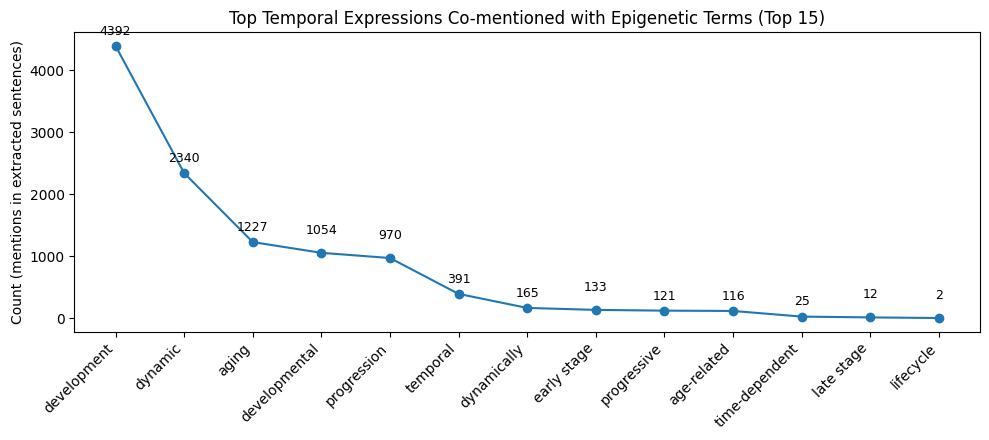

Saved Figure 1:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/postproc_temporal_epi/Figure1_top_temporal_terms_line_TOP15.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/postproc_temporal_epi/Figure1_top_temporal_terms_line_TOP15.pdf


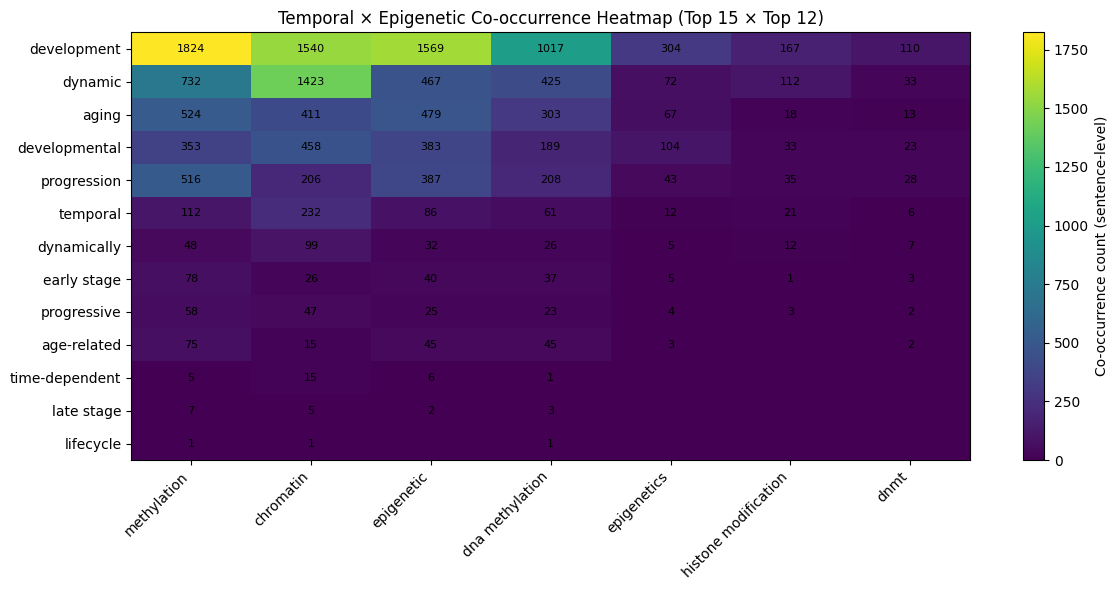

Saved Figure 2:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/postproc_temporal_epi/Figure2_heatmap_temporal_x_epigenetic_TOP15xTOP12.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/postproc_temporal_epi/Figure2_heatmap_temporal_x_epigenetic_TOP15xTOP12.pdf

 DONE. Outputs folder:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/postproc_temporal_epi


In [ ]:
# =========================
# Google Drive 마운트 (Colab에서 Drive 접근)
# =========================
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) 경로 설정
# =========================
# INPUT_CSV: 이전 단계에서 만든 문장 기반 추출 결과 CSV
# OUT_DIR: 후처리 결과(테이블/행렬/그림) 저장 폴더
INPUT_CSV = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126/temporal_epigenetics_sentences_6152.csv"
OUT_DIR = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126/postproc_temporal_epi"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# 2) 파라미터 설정
# =========================
TOP_TEMPORAL = 15                 # Temporal 표현 상위 몇 개를 볼지
TOP_EPI = 12                      # Epigenetic 용어 상위 몇 개를 볼지
HEATMAP_CELL_THRESHOLD = 1        # 히트맵 셀 내부 값 표시 최소 기준(1 이상 표시)

# =========================
# 3) CSV 로드
# =========================
df = pd.read_csv(INPUT_CSV, encoding="utf-8-sig")
print("Loaded rows:", len(df))          # 입력 CSV 행 수(추출된 문장 수)
print("Columns:", list(df.columns))    # 컬럼 목록 확인

# =========================
# 4) 문자열 리스트 분해
# =========================
# temporal_terms, epigenetic_terms 컬럼은 보통 "term1; term2; term3" 형태이므로
# 이를 리스트로 변환하는 함수
def split_terms(x):
    if pd.isna(x):
        return []
    return [t.strip() for t in str(x).split(";") if t.strip()]

# 각 행(문장)별로 temporal/epi term 리스트 컬럼 생성
df["temporal_list"] = df["temporal_terms"].apply(split_terms)
df["epi_list"] = df["epigenetic_terms"].apply(split_terms)

# explode:
# - 리스트를 행으로 늘려서(term 하나당 1행) 빈도 계산을 쉽게 함
temporal_long = df[["file", "temporal_list"]].explode("temporal_list").dropna()
temporal_long = temporal_long.rename(columns={"temporal_list": "temporal_term"})

epi_long = df[["file", "epi_list"]].explode("epi_list").dropna()
epi_long = epi_long.rename(columns={"epi_list": "epigenetic_term"})

# =========================
# 5) 상위 빈도 목록(테이블) 생성
# =========================
# value_counts: "추출된 문장들"에서 term이 등장한 횟수(언급 횟수)
temporal_counts = temporal_long["temporal_term"].value_counts().sort_values(ascending=False)
epi_counts = epi_long["epigenetic_term"].value_counts().sort_values(ascending=False)

# 상위 N개만 선택
top_temporal = temporal_counts.head(TOP_TEMPORAL)
top_epi = epi_counts.head(TOP_EPI)

# 테이블 형태로 변환
top_temporal_df = top_temporal.reset_index()
top_temporal_df.columns = ["temporal_term", "count_mentions_in_extracted_sentences"]

top_epi_df = top_epi.reset_index()
top_epi_df.columns = ["epigenetic_term", "count_mentions_in_extracted_sentences"]

# 저장 경로
table_temporal_path = os.path.join(OUT_DIR, f"Table_top_temporal_terms_TOP{TOP_TEMPORAL}.csv")
table_epi_path = os.path.join(OUT_DIR, f"Table_top_epigenetic_terms_TOP{TOP_EPI}.csv")

# CSV 저장
top_temporal_df.to_csv(table_temporal_path, index=False, encoding="utf-8-sig")
top_epi_df.to_csv(table_epi_path, index=False, encoding="utf-8-sig")

print("Saved tables:")
print(" -", table_temporal_path)
print(" -", table_epi_path)

# =========================
# 6) 동시출현(co-occurrence) 행렬 생성 (Temporal × Epigenetic)
#   기준: "같은 행(문장)"에서 temporal term과 epigenetic term이 동시에 등장하면 1 카운트
# =========================
rows = []
for _, r in df.iterrows():
    ts = split_terms(r.get("temporal_terms", ""))
    es = split_terms(r.get("epigenetic_terms", ""))

    # 히트맵을 깔끔하게 만들기 위해 상위 TOP 범위만 사용
    ts = [t for t in ts if t in top_temporal.index]
    es = [e for e in es if e in top_epi.index]

    # 같은 문장(행) 안에서 temporal-term × epi-term 조합을 모두 수집
    for t in ts:
        for e in es:
            rows.append((t, e))

# rows를 데이터프레임으로 만든 뒤 crosstab으로 행렬화
cooc = pd.DataFrame(rows, columns=["temporal_term", "epigenetic_term"])

if len(cooc) == 0:
    # TOP 범위가 너무 작거나 데이터가 적어서 동시출현이 하나도 없을 때
    print("Co-occurrence rows are 0. TOP 범위를 늘려보세요.")
    heat = pd.DataFrame(0, index=list(top_temporal.index), columns=list(top_epi.index))
else:
    # crosstab: (temporal_term, epigenetic_term) 조합별 빈도(=동시출현 문장 수) 계산
    heat = pd.crosstab(cooc["temporal_term"], cooc["epigenetic_term"])
    # 인덱스/컬럼 순서를 top 리스트 순서로 맞추고, 없는 조합은 0으로 채움
    heat = heat.reindex(index=list(top_temporal.index), columns=list(top_epi.index), fill_value=0)

# 행렬 CSV 저장
heat_path = os.path.join(OUT_DIR, f"Matrix_temporal_x_epigenetic_TOP{TOP_TEMPORAL}xTOP{TOP_EPI}.csv")
heat.to_csv(heat_path, encoding="utf-8-sig")
print("Saved matrix:")
print(" -", heat_path)

# =========================
# 7) Figure 1: Temporal 상위 표현 선그래프 + 값 라벨
# =========================
plt.figure(figsize=(10, 4.5))

x_labels = list(top_temporal.index)    # x축 라벨: temporal 표현
y_vals = list(top_temporal.values)     # y축 값: 추출된 문장에서의 언급 횟수
x = list(range(len(x_labels)))

plt.plot(x, y_vals, marker="o")
plt.xticks(x, x_labels, rotation=45, ha="right")
plt.ylabel("Count (mentions in extracted sentences)")
plt.title(f"Top Temporal Expressions Co-mentioned with Epigenetic Terms (Top {TOP_TEMPORAL})")

# 값 라벨 겹침 완화(오프셋)
y_max = max(y_vals) if len(y_vals) else 1
base_offset = max(1, int(y_max * 0.03))
close_thresh = max(1, int(y_max * 0.02))

for i, val in enumerate(y_vals):
    dy = base_offset
    # 이웃 값이 너무 가까우면 라벨 위치를 번갈아 더 띄워 겹침 완화
    if i > 0 and abs(val - y_vals[i-1]) <= close_thresh:
        dy = base_offset * (2 if i % 2 == 0 else 1)
    if i < len(y_vals)-1 and abs(val - y_vals[i+1]) <= close_thresh:
        dy = base_offset * (2 if i % 2 == 1 else 1)

    plt.text(i, val + dy, str(int(val)), ha="center", va="bottom", fontsize=9)

plt.tight_layout()

# 그림 저장(논문용 600dpi PNG + PDF)
fig1_png = os.path.join(OUT_DIR, f"Figure1_top_temporal_terms_line_TOP{TOP_TEMPORAL}.png")
fig1_pdf = os.path.join(OUT_DIR, f"Figure1_top_temporal_terms_line_TOP{TOP_TEMPORAL}.pdf")
plt.savefig(fig1_png, dpi=600)
plt.savefig(fig1_pdf)
plt.show()

print("Saved Figure 1:")
print(" -", fig1_png)
print(" -", fig1_pdf)

# =========================
# 8) Figure 2: Temporal × Epigenetic 히트맵 + 셀 내부 값
# =========================
plt.figure(figsize=(12, 6))

# heat.values: (temporal_term × epigenetic_term) 동시출현 빈도 행렬
im = plt.imshow(heat.values, aspect="auto")
plt.xticks(range(len(heat.columns)), list(heat.columns), rotation=45, ha="right")
plt.yticks(range(len(heat.index)), list(heat.index))
plt.colorbar(im, label="Co-occurrence count (sentence-level)")
plt.title(f"Temporal × Epigenetic Co-occurrence Heatmap (Top {TOP_TEMPORAL} × Top {TOP_EPI})")

# 셀 내부 숫자 표기(threshold 이상만)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = int(heat.iat[i, j])
        if val >= HEATMAP_CELL_THRESHOLD:
            plt.text(j, i, str(val), ha="center", va="center", fontsize=8)

plt.tight_layout()

# 그림 저장(논문용 600dpi PNG + PDF)
fig2_png = os.path.join(OUT_DIR, f"Figure2_heatmap_temporal_x_epigenetic_TOP{TOP_TEMPORAL}xTOP{TOP_EPI}.png")
fig2_pdf = os.path.join(OUT_DIR, f"Figure2_heatmap_temporal_x_epigenetic_TOP{TOP_TEMPORAL}xTOP{TOP_EPI}.pdf")
plt.savefig(fig2_png, dpi=600)
plt.savefig(fig2_pdf)
plt.show()

print("Saved Figure 2:")
print(" -", fig2_png)
print(" -", fig2_pdf)

print("\n DONE. Outputs folder:")
print(" -", OUT_DIR)

**7. Environmental Epigenetics Mining**

Mounted at /content/drive
Found documents: 6152
Processed 1/6152 docs...
Processed 200/6152 docs...
Processed 400/6152 docs...
Processed 600/6152 docs...
Processed 800/6152 docs...
Processed 1000/6152 docs...
Processed 1200/6152 docs...
Processed 1400/6152 docs...
Processed 1600/6152 docs...
Processed 1800/6152 docs...
Processed 2000/6152 docs...
Processed 2200/6152 docs...
Processed 2400/6152 docs...
Processed 2600/6152 docs...
Processed 2800/6152 docs...
Processed 3000/6152 docs...
Processed 3200/6152 docs...
Processed 3400/6152 docs...
Processed 3600/6152 docs...
Processed 3800/6152 docs...
Processed 4000/6152 docs...
Processed 4200/6152 docs...
Processed 4400/6152 docs...
Processed 4600/6152 docs...
Processed 4800/6152 docs...
Processed 5000/6152 docs...
Processed 5200/6152 docs...
Processed 5400/6152 docs...
Processed 5600/6152 docs...
Processed 5800/6152 docs...
Processed 6000/6152 docs...
Processed 6152/6152 docs...
Extraction finished.
Total extracted sentences: 2516


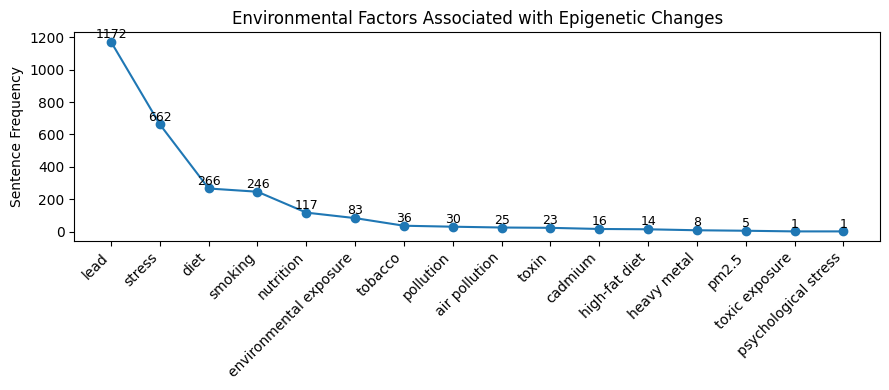

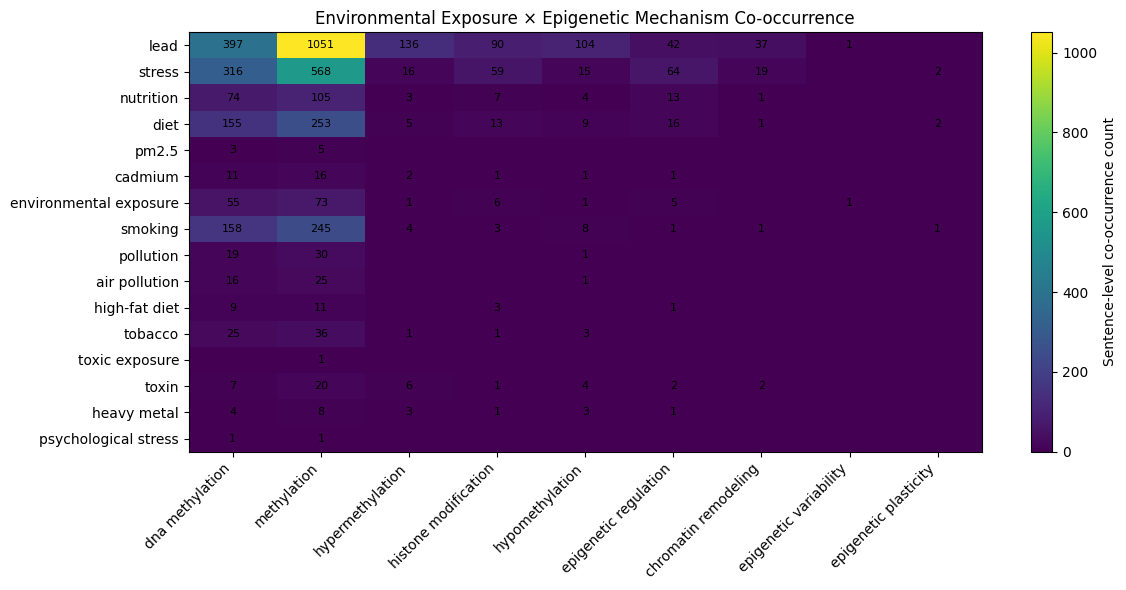

In [ ]:
# =========================
# Google Drive 마운트 (Colab에서 Drive 접근)
# =========================
from google.colab import drive
drive.mount('/content/drive')

import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

# =========================
# 1) 경로 설정
# =========================
# CORPUS_DIR: 분석할 full-text(.txt) 파일 폴더
# OUT_DIR: 결과 CSV/그림 저장 폴더
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"
OUT_DIR = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# 2) 키워드 설정
# =========================
# environmental_terms:
# - 환경 요인/노출 관련 표현
# - 식이, 스트레스, 오염, 중금속, 흡연 등 포함
environmental_terms = [
    "smoking", "tobacco",
    "diet", "nutrition", "high-fat diet",
    "stress", "psychological stress",
    "pollution", "air pollution", "pm2.5",
    "toxin", "toxic exposure",
    "heavy metal", "lead", "cadmium",
    "environmental exposure"
]

# epigenetic_terms:
# - 후성유전 기전/특성 관련 표현
epigenetic_terms = [
    "dna methylation",
    "methylation",
    "hypermethylation",
    "hypomethylation",
    "histone modification",
    "chromatin remodeling",
    "epigenetic regulation",
    "epigenetic variability",
    "epigenetic plasticity"
]

# 문서당 최대 추출 문장 수(과도한 특정 문서 영향 방지)
MAX_SENTENCES_PER_DOC = 5

# 몇 문서마다 진행 상황 출력할지
PROGRESS_EVERY = 200

# =========================
# 3) 전처리 함수
# =========================
def load_txt_files(folder):
    """
    지정 폴더 내 .txt 파일을 모두 읽어
    (파일명, 텍스트) 리스트로 반환
    """
    docs = []
    for fn in sorted(os.listdir(folder)):
        if fn.lower().endswith(".txt"):
            with open(os.path.join(folder, fn),
                      "r", encoding="utf-8", errors="ignore") as f:
                docs.append((fn, f.read()))
    return docs

def split_sentences(text):
    """
    문장 분리:
    . ! ? 뒤의 공백을 기준으로 분리
    (간단하지만 대규모 full-text 분석에 충분히 사용 가능)
    """
    return re.split(r"(?<=[.!?])\s+", text)

# =========================
# 4) 코퍼스 로드
# =========================
docs = load_txt_files(CORPUS_DIR)
print("Found documents:", len(docs))

# =========================
# 5) 핵심 추출 로직
# =========================
# results:
# - 최종 CSV에 저장할 문장 단위 결과
results = []

# env_counter:
# - 각 environmental term이 "추출된 문장들"에서 등장한 횟수
env_counter = Counter()

# cooc:
# - 환경 요인 × 후성유전 용어 문장 단위 동시출현 횟수
# - 구조: cooc[environment_term][epigenetic_term] = count
cooc = defaultdict(lambda: Counter())

for i, (filename, text) in enumerate(docs, 1):

    # 문장 분리
    sentences = split_sentences(text)

    extracted = 0  # 현재 문서에서 추출한 문장 수

    for sent in sentences:
        if extracted >= MAX_SENTENCES_PER_DOC:
            break

        sent_lower = sent.lower()

        # 현재 문장에 포함된 환경 요인
        env_hits = [e for e in environmental_terms if e in sent_lower]

        # 현재 문장에 포함된 후성유전 용어
        epi_hits = [k for k in epigenetic_terms if k in sent_lower]

        # 환경 요인 + 후성유전 용어가 동시에 등장한 문장만 사용
        if env_hits and epi_hits:

            # 빈도/동시출현 카운트
            for e in env_hits:
                env_counter[e] += 1
                for k in epi_hits:
                    cooc[e][k] += 1

            # CSV용 결과 저장
            results.append({
                "file": filename,
                "environmental_terms": "; ".join(sorted(set(env_hits))),
                "epigenetic_terms": "; ".join(sorted(set(epi_hits))),
                "sentence": sent.strip()
            })

            extracted += 1

    # 진행률 출력
    if i % PROGRESS_EVERY == 0 or i == 1 or i == len(docs):
        print(f"Processed {i}/{len(docs)} docs...")

print("Extraction finished.")
print("Total extracted sentences:", len(results))

# =========================
# 6) CSV 저장
# =========================
out_csv = os.path.join(
    OUT_DIR, "environmental_epigenetics_sentences_6152.csv"
)
pd.DataFrame(results).to_csv(out_csv, index=False, encoding="utf-8-sig")

# =========================
# 7) FIGURE A: 환경 요인 빈도 선그래프
# =========================
# env_counter:
# - 환경 요인이 추출된 문장에서 등장한 횟수
env_df = pd.Series(env_counter).sort_values(ascending=False)

plt.figure(figsize=(9,4))
plt.plot(range(len(env_df)), env_df.values, marker="o")
plt.xticks(range(len(env_df)), env_df.index, rotation=45, ha="right")
plt.ylabel("Sentence Frequency")
plt.title("Environmental Factors Associated with Epigenetic Changes")

# 값 라벨 표시
for i, v in enumerate(env_df.values):
    plt.text(i, v + max(env_df.values)*0.02, str(v),
             ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "Figure_env_epigenetics_line.png"), dpi=600)
plt.savefig(os.path.join(OUT_DIR, "Figure_env_epigenetics_line.pdf"))
plt.show()

# =========================
# 8) FIGURE B: 히트맵 (환경 요인 × 후성유전)
# =========================
# cooc 딕셔너리를 DataFrame으로 변환
heatmap_df = pd.DataFrame(cooc).fillna(0).T
# 행: environmental term
# 열: epigenetic term
# 값: 문장 단위 동시출현 횟수

plt.figure(figsize=(12,6))
im = plt.imshow(heatmap_df.values, aspect="auto")
plt.xticks(range(len(heatmap_df.columns)),
           heatmap_df.columns, rotation=45, ha="right")
plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)
plt.colorbar(im, label="Sentence-level co-occurrence count")
plt.title("Environmental Exposure × Epigenetic Mechanism Co-occurrence")

# 셀 내부 값 표시
for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        val = int(heatmap_df.iat[i, j])
        if val > 0:
            plt.text(j, i, str(val),
                     ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "Figure_env_epigenetics_heatmap.png"), dpi=600)
plt.savefig(os.path.join(OUT_DIR, "Figure_env_epigenetics_heatmap.pdf"))
plt.show()

**8. Epigenetic Variability Semantic Network**

Mounted at /content/drive
 Found .txt files: 6152
Processed 1/6152 docs...  | matched_docs=0 | used_sentences=0
Processed 200/6152 docs...  | matched_docs=13 | used_sentences=21
Processed 400/6152 docs...  | matched_docs=30 | used_sentences=44
Processed 600/6152 docs...  | matched_docs=42 | used_sentences=65
Processed 800/6152 docs...  | matched_docs=56 | used_sentences=81
Processed 1000/6152 docs...  | matched_docs=72 | used_sentences=108
Processed 1200/6152 docs...  | matched_docs=90 | used_sentences=141
Processed 1400/6152 docs...  | matched_docs=107 | used_sentences=177
Processed 1600/6152 docs...  | matched_docs=118 | used_sentences=188
Processed 1800/6152 docs...  | matched_docs=131 | used_sentences=223
Processed 2000/6152 docs...  | matched_docs=140 | used_sentences=234
Processed 2200/6152 docs...  | matched_docs=149 | used_sentences=249
Processed 2400/6152 docs...  | matched_docs=160 | used_sentences=273
Processed 2600/6152 docs...  | matched_docs=167 | used_sentences=288
Proce

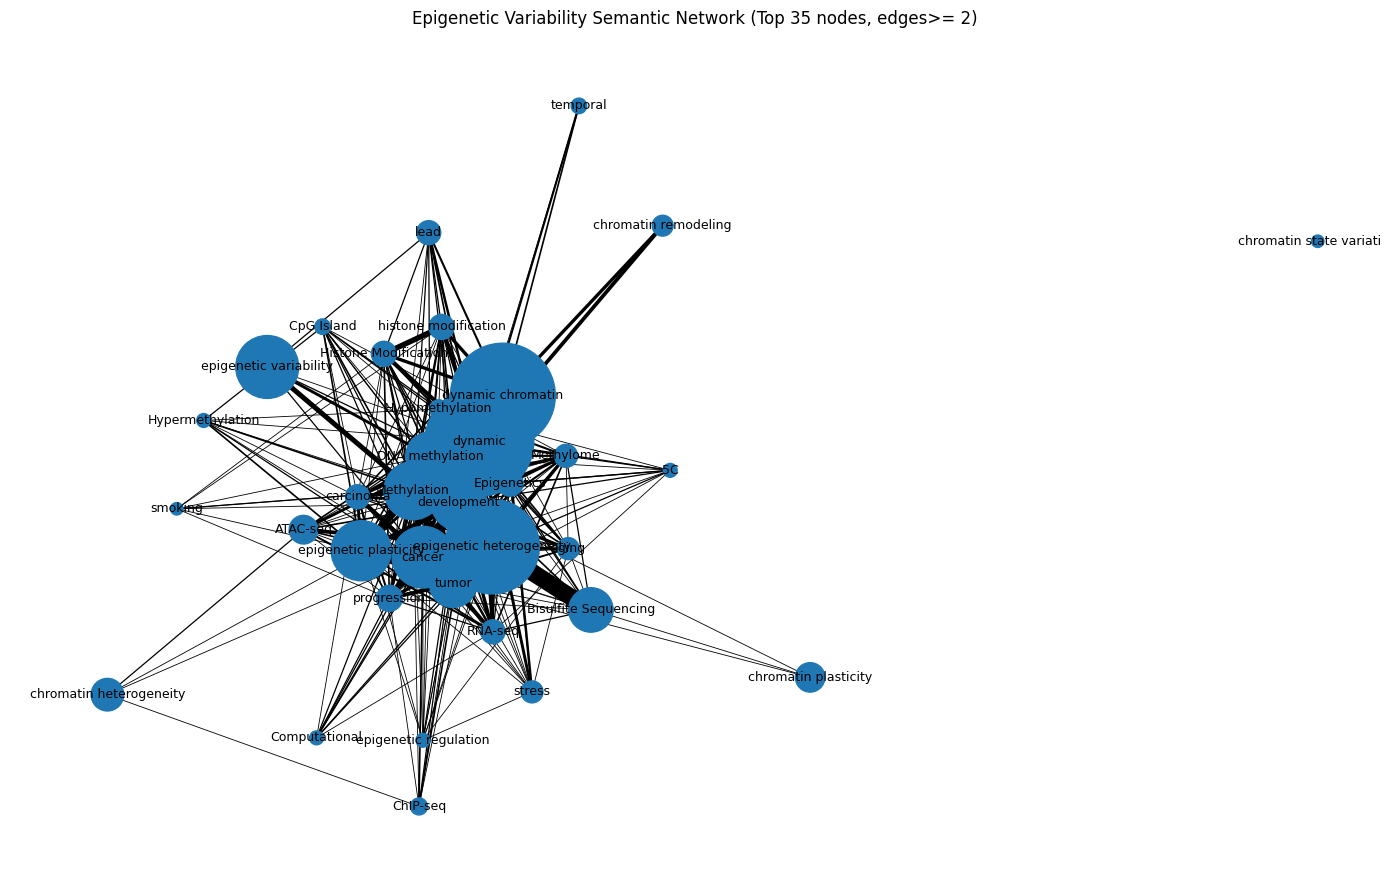


 Saved figure:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/semantic_network_240126/Figure_semantic_network_top35_edgesge2.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/semantic_network_240126/Figure_semantic_network_top35_edgesge2.pdf


In [ ]:
# =========================
# Google Drive 마운트 (Colab에서 Drive 접근)
# =========================
from google.colab import drive
drive.mount('/content/drive')

import os
import re
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# =========================
# 1) 경로 설정
# =========================
# CORPUS_DIR: 분석할 full-text(.txt) 파일 폴더
# OUT_DIR: 결과(노드/엣지 CSV, 네트워크 그림) 저장 폴더
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"
OUT_DIR   = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126/semantic_network_240126"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# 2) 키워드
# =========================
# assay_keywords: 실험/분석 기법 키워드
assay_keywords = [
    "5C", "ChIA-PET", "Hi-C", "DNase-seq", "FAIRE-seq", "ATAC-seq", "ChIP-seq",
    "WGBS", "RRBS", "methylation array", "Computational", "predictions",
    "RNA-seq", "CLIP-seq", "RIP-seq", "Histone Modification"
]

# methylation_keywords: methylation/epigenetics 관련 개념 키워드
methylation_keywords = [
    "Methylation", "CpG Island", "Hypermethylation", "Hypomethylation",
    "Epigenetics", "Histone Modification", "Gene Silencing", "DNMT",
    "Methylome", "Bisulfite Sequencing"
]

# mechanisms: epigenetic mechanism 키워드
mechanisms = [
    "DNA methylation",
    "histone modification",
    "chromatin remodeling",
    "noncoding RNA",
    "epigenetic regulation"
]

# disease_keywords: 질병 관련 키워드(간단 set)
disease_keywords = [
    "cancer", "tumor", "carcinoma",
    "diabetes",
    "alzheimer", "parkinson",
    "schizophrenia", "autism"
]

# temporal_terms: 시간적/발달/노화/진행 등 관련 용어(축소 set)
temporal_terms = ["development", "aging", "dynamic", "temporal", "progression"]

# environmental_terms: 환경 노출/요인 키워드
environmental_terms = [
    "smoking", "tobacco",
    "diet", "nutrition", "high-fat diet",
    "stress", "psychological stress",
    "pollution", "air pollution", "pm2.5",
    "toxin", "toxic exposure",
    "heavy metal", "lead", "cadmium",
    "environmental exposure"
]

# variability_patterns:
# - 이 패턴이 포함된 문장만 "네트워크 구성 대상 문장"으로 사용
# - 즉, epigenetic/chromatin variability(가변성/이질성/가소성) 문장만 골라 분석
variability_patterns = [
    "chromatin variability",
    "chromatin heterogeneity",
    "dynamic chromatin",
    "chromatin plasticity",
    "chromatin state variation",
    "epigenetic variability",
    "epigenetic plasticity",
    "epigenetic heterogeneity"
]

# =========================
# 3) 파라미터
# =========================
PROGRESS_EVERY = 200          # 진행률 출력 간격(문서 단위)
MAX_SENTENCES_PER_DOC = 2000  # 문서가 너무 길 경우 문장 수 상한(안정장치)
PLOT_TOP_N_NODES = 35         # 시각화는 너무 크면 복잡 → 상위 N 노드만 그림
EDGE_MIN_WEIGHT_TO_PLOT = 2   # 공출현 1회짜리 엣지가 너무 많으면 지저분 → 2 이상만 그림에 표시
RANDOM_SEED = 42              # spring_layout 재현성 확보(같은 모양 유지)

# =========================
# 4) 전처리 함수
# =========================
def normalize_text(t: str) -> str:
    """소문자화 + 공백 정리(정규화)"""
    t = t.lower()
    t = re.sub(r"\s+", " ", t)
    return t

def split_sentences(text: str):
    """간단 문장 분리(.!? 뒤 공백 기준) - 대용량 안정 목적"""
    return re.split(r"(?<=[.!?])\s+", text)

def load_txt_files_from_folder(folder_path: str):
    """폴더 내 .txt 파일을 모두 읽어 (파일명, 텍스트) 리스트로 반환"""
    files = []
    for fn in sorted(os.listdir(folder_path)):
        if fn.lower().endswith(".txt"):
            fp = os.path.join(folder_path, fn)
            with open(fp, "r", encoding="utf-8", errors="ignore") as f:
                files.append((fn, f.read()))
    return files

def find_hits_in_sentence(sent_lower: str, term_list):
    """
    문장(sent_lower)에 term_list의 용어들이 포함되는지 검사해 hit 리스트 반환
    - term이 여러 단어일 수 있으므로 단순 포함(in) 매칭 사용
    """
    hits = []
    for t in term_list:
        if t.lower() in sent_lower:
            hits.append(t)
    return hits

# =========================
# 5) 코퍼스 로드
# =========================
docs = load_txt_files_from_folder(CORPUS_DIR)
total_docs = len(docs)
print(" Found .txt files:", total_docs)

# =========================
# 6) 문장 단위 공출현(co-occurrence) 계산
# =========================
# node_freq: 노드(키워드)별 문장 등장 빈도(= sentence frequency)
node_freq = Counter()

# edge_w: 엣지(키워드 쌍)별 공출현 가중치(= 같은 문장에서 함께 등장한 횟수)
edge_w = defaultdict(int)

used_sentences = 0  # variability_patterns에 걸려 실제 분석에 사용된 문장 수
matched_docs = 0    # variability_patterns 문장이 하나라도 있었던 문서 수

# 개념 그룹(분석 대상 키워드 묶음)
all_concept_groups = {
    "ASSAY": assay_keywords,
    "METHYLATION": methylation_keywords,
    "MECHANISM": mechanisms,
    "DISEASE": disease_keywords,
    "TEMPORAL": temporal_terms,
    "ENVIRONMENT": environmental_terms,
    "VARIABILITY": variability_patterns,  # variability 자체도 노드로 포함(원하면 제외 가능)
}

# 네트워크 노드 후보 전체(term 리스트를 한 번에 펼침)
all_terms_flat = []
for _, lst in all_concept_groups.items():
    all_terms_flat.extend(lst)

# 문서별 처리
for i, (filename, text) in enumerate(docs, 1):
    text_norm = normalize_text(text)
    sents = split_sentences(text_norm)

    # 문서가 너무 길면 문장 수를 제한(안정장치)
    if len(sents) > MAX_SENTENCES_PER_DOC:
        sents = sents[:MAX_SENTENCES_PER_DOC]

    doc_has_match = False  # 이 문서에서 variability 문장을 하나라도 사용했는지

    for sent in sents:
        sent_lower = sent  # 이미 lower 상태

        # (핵심) variability_patterns가 포함된 문장만 사용
        if not any(p.lower() in sent_lower for p in variability_patterns):
            continue

        doc_has_match = True
        used_sentences += 1

        # 해당 문장에 등장한 "연구 키워드"를 모두 수집
        hits = []
        for term in all_terms_flat:
            if term.lower() in sent_lower:
                hits.append(term)

        # 중복 제거(한 문장에서 같은 term이 여러 번 등장해도 1회 hit로 처리)
        hits = sorted(set(hits))

        # 노드 빈도 업데이트: term이 등장한 문장 수 누적
        for h in hits:
            node_freq[h] += 1

        # 엣지 가중치 업데이트:
        # - 같은 문장에서 함께 등장한 term 쌍마다 +1
        for a_idx in range(len(hits)):
            for b_idx in range(a_idx + 1, len(hits)):
                a, b = hits[a_idx], hits[b_idx]
                edge_w[(a, b)] += 1

    # 이 문서에서 variability 문장을 하나라도 사용했다면 matched_docs 증가
    if doc_has_match:
        matched_docs += 1

    # 진행률 출력
    if i % PROGRESS_EVERY == 0 or i == 1 or i == total_docs:
        print(f"Processed {i}/{total_docs} docs...  | matched_docs={matched_docs} | used_sentences={used_sentences}")

print("\n DONE extraction")
print(" - Docs with variability sentences:", matched_docs)
print(" - Variability sentences used:", used_sentences)
print(" - Unique nodes:", len(node_freq))
print(" - Unique edges:", len(edge_w))

# =========================
# 7) 노드/엣지 테이블 저장
# =========================
# nodes_df: 각 term(노드)의 문장 등장 빈도
nodes_df = pd.DataFrame({
    "term": list(node_freq.keys()),
    "sentence_frequency": list(node_freq.values())
}).sort_values("sentence_frequency", ascending=False)

# edges_df: 각 term 쌍(엣지)의 공출현 횟수(문장 단위)
edges_df = pd.DataFrame([
    {"term1": a, "term2": b, "cooc_sentence_count": w}
    for (a, b), w in edge_w.items()
]).sort_values("cooc_sentence_count", ascending=False)

nodes_path = os.path.join(OUT_DIR, "semantic_network_nodes_sentence_freq.csv")
edges_path = os.path.join(OUT_DIR, "semantic_network_edges_sentence_cooc.csv")
nodes_df.to_csv(nodes_path, index=False, encoding="utf-8-sig")
edges_df.to_csv(edges_path, index=False, encoding="utf-8-sig")

print("\n Saved tables:")
print(" -", nodes_path)
print(" -", edges_path)

# =========================
# 8) 그래프(NetworkX) 생성
# =========================
G = nx.Graph()

# 노드 추가: freq 속성에 문장 빈도 저장
for _, r in nodes_df.iterrows():
    G.add_node(r["term"], freq=int(r["sentence_frequency"]))

# 엣지 추가: weight 속성에 공출현 횟수 저장
for _, r in edges_df.iterrows():
    G.add_edge(r["term1"], r["term2"], weight=int(r["cooc_sentence_count"]))

# =========================
# 9) 시각화(상위 N 노드만)
# =========================
# 상위 N개의 노드(term)만 선택(가독성 확보)
top_nodes = set(nodes_df.head(PLOT_TOP_N_NODES)["term"].tolist())

# 상위 노드들로만 서브그래프 H 구성
H = nx.Graph()

# 노드 추가(상위 노드만)
for n in top_nodes:
    if n in G:
        H.add_node(n, freq=G.nodes[n]["freq"])

# 엣지 추가(상위 노드 사이 + 가중치 threshold 이상만)
for (u, v, d) in G.edges(data=True):
    if u in top_nodes and v in top_nodes and d.get("weight", 0) >= EDGE_MIN_WEIGHT_TO_PLOT:
        H.add_edge(u, v, weight=d["weight"])

print("\n Plot subgraph:")
print(" - nodes:", H.number_of_nodes())
print(" - edges:", H.number_of_edges())

# 레이아웃 계산(spring_layout), seed 고정으로 재현성 확보
pos = nx.spring_layout(H, seed=RANDOM_SEED, k=0.8)

# 노드 크기: freq(문장 빈도)에 비례(최소 80)
node_sizes = []
for n in H.nodes():
    node_sizes.append(max(80, H.nodes[n]["freq"] * 25))

# 엣지 두께: weight(공출현 횟수)에 비례(최소 0.5)
edge_widths = []
for (u, v, d) in H.edges(data=True):
    edge_widths.append(max(0.5, d["weight"] * 0.3))

plt.figure(figsize=(14, 9))
nx.draw_networkx_nodes(H, pos, node_size=node_sizes)
nx.draw_networkx_edges(H, pos, width=edge_widths)
nx.draw_networkx_labels(H, pos, font_size=9)

plt.title(f"Epigenetic Variability Semantic Network (Top {PLOT_TOP_N_NODES} nodes, edges>= {EDGE_MIN_WEIGHT_TO_PLOT})")
plt.axis("off")
plt.tight_layout()

# 논문용 저장(600dpi PNG + 벡터 PDF)
fig_png = os.path.join(OUT_DIR, f"Figure_semantic_network_top{PLOT_TOP_N_NODES}_edgesge{EDGE_MIN_WEIGHT_TO_PLOT}.png")
fig_pdf = os.path.join(OUT_DIR, f"Figure_semantic_network_top{PLOT_TOP_N_NODES}_edgesge{EDGE_MIN_WEIGHT_TO_PLOT}.pdf")
plt.savefig(fig_png, dpi=600)
plt.savefig(fig_pdf)
plt.show()

print("\n Saved figure:")
print(" -", fig_png)
print(" -", fig_pdf)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Found .txt files: 6152
Processed 1/6152 docs...  | matched_docs=0 | used_sentences=0
Processed 200/6152 docs...  | matched_docs=13 | used_sentences=21
Processed 400/6152 docs...  | matched_docs=30 | used_sentences=44
Processed 600/6152 docs...  | matched_docs=42 | used_sentences=65
Processed 800/6152 docs...  | matched_docs=56 | used_sentences=81
Processed 1000/6152 docs...  | matched_docs=72 | used_sentences=108
Processed 1200/6152 docs...  | matched_docs=90 | used_sentences=141
Processed 1400/6152 docs...  | matched_docs=107 | used_sentences=177
Processed 1600/6152 docs...  | matched_docs=118 | used_sentences=188
Processed 1800/6152 docs...  | matched_docs=131 | used_sentences=223
Processed 2000/6152 docs...  | matched_docs=140 | used_sentences=234
Processed 2200/6152 docs...  | matched_docs=149 | used_sentences=249
Processed 2400/6152 docs...  | matched_d

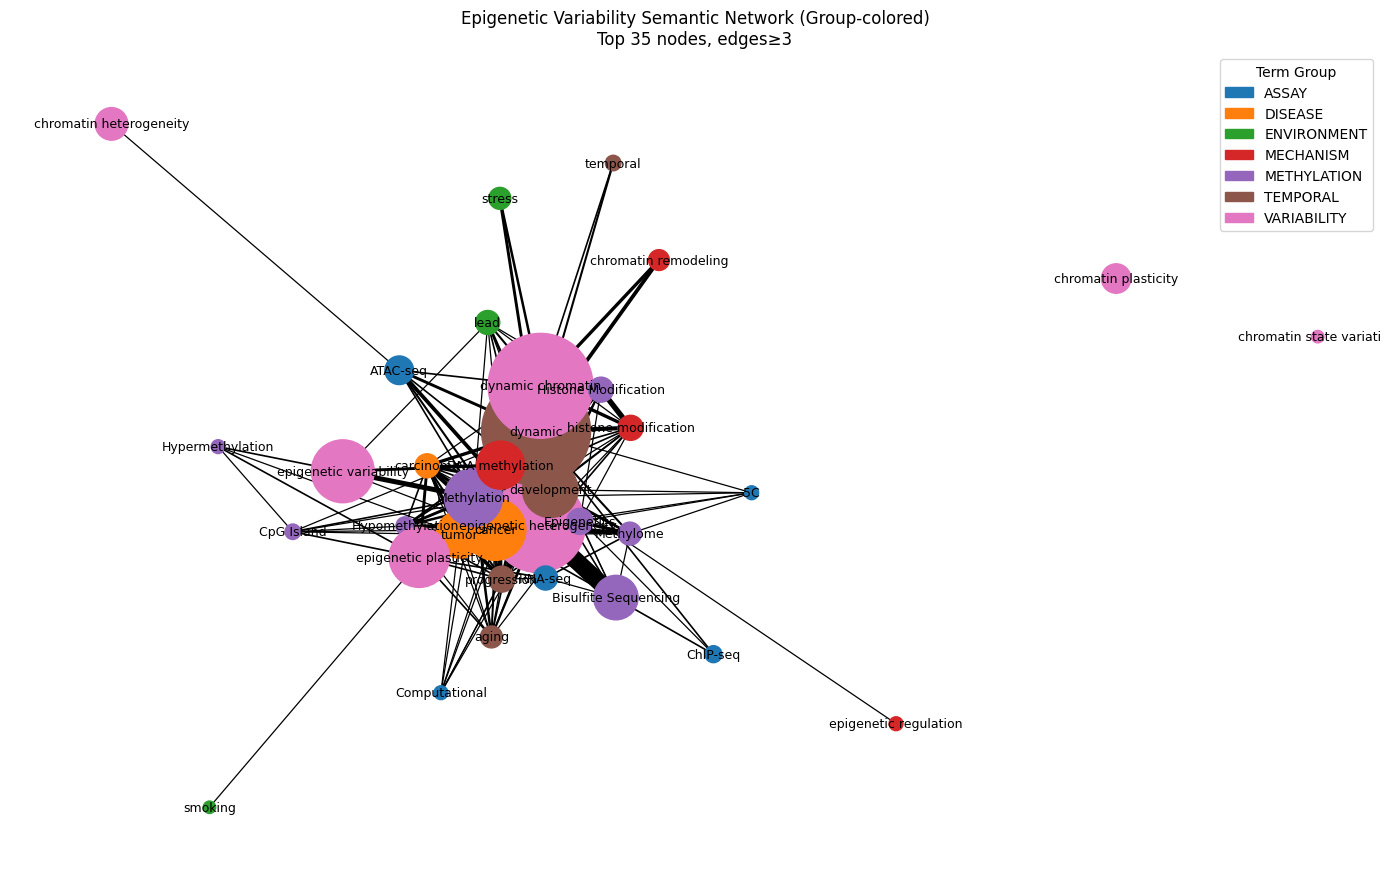


 Saved group-colored figure:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/semantic_network_240126_colored_ad/Figure_semantic_network_group_colored_top35_edgesge3_ad.png
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/semantic_network_240126_colored_ad/Figure_semantic_network_group_colored_top35_edgesge3_ad.pdf

 DONE. Output folder:
 - /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/semantic_network_240126_colored_ad


In [ ]:
# =========================
# Google Drive 마운트 (Colab에서 Drive 접근)
# =========================
from google.colab import drive
drive.mount('/content/drive')

import os
import re
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# =========================
# 1) 경로 설정
# =========================
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"
OUT_DIR   = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126/semantic_network_240126_colored_ad"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# 2) 키워드
# =========================
assay_keywords = [
    "5C", "ChIA-PET", "Hi-C", "DNase-seq", "FAIRE-seq", "ATAC-seq", "ChIP-seq",
    "WGBS", "RRBS", "methylation array", "Computational", "predictions",
    "RNA-seq", "CLIP-seq", "RIP-seq", "Histone Modification"
]

methylation_keywords = [
    "Methylation", "CpG Island", "Hypermethylation", "Hypomethylation",
    "Epigenetics", "Histone Modification", "Gene Silencing", "DNMT",
    "Methylome", "Bisulfite Sequencing"
]

mechanisms = [
    "DNA methylation",
    "histone modification",
    "chromatin remodeling",
    "noncoding RNA",
    "epigenetic regulation"
]

disease_keywords = [
    "cancer", "tumor", "carcinoma",
    "diabetes",
    "alzheimer", "parkinson",
    "schizophrenia", "autism"
]

temporal_terms = ["development", "aging", "dynamic", "temporal", "progression"]

environmental_terms = [
    "smoking", "tobacco",
    "diet", "nutrition", "high-fat diet",
    "stress", "psychological stress",
    "pollution", "air pollution", "pm2.5",
    "toxin", "toxic exposure",
    "heavy metal", "lead", "cadmium",
    "environmental exposure"
]

# variability_patterns:
# - 이 패턴이 포함된 문장만 분석에 사용(네트워크 구성 문장)
variability_patterns = [
    "chromatin variability",
    "chromatin heterogeneity",
    "dynamic chromatin",
    "chromatin plasticity",
    "chromatin state variation",
    "epigenetic variability",
    "epigenetic plasticity",
    "epigenetic heterogeneity"
]

# =========================
# 3) 파라미터 설정
# =========================
PROGRESS_EVERY = 200          # 진행률 출력 간격(문서 단위)
MAX_SENTENCES_PER_DOC = 2000  # 문서가 너무 길 때 문장 수 상한(안전장치)

# 시각화용 서브그래프 설정(너무 큰 그래프 방지)
PLOT_TOP_N_NODES = 35         # 노드 빈도 상위 N개만 그림(가독성)
EDGE_MIN_WEIGHT_TO_PLOT = 3   # 공출현 3회 이상인 엣지만 그림에 포함(고립 노드 완화)

RANDOM_SEED = 42              # spring_layout 재현성

# 중심성 결과 테이블 출력 관련
CENTRALITY_TOP_K = 30
BETWEENNESS_ON_SUBGRAPH = True  # betweenness는 계산 비용이 커서 보통 서브그래프(H)에서 계산

# =========================
# 4) 전처리 함수
# =========================
def normalize_text(t: str) -> str:
    """소문자화 + 공백 정리"""
    t = t.lower()
    t = re.sub(r"\s+", " ", t)
    return t

def split_sentences(text: str):
    """간단 문장 분리(.!? 뒤 공백 기준)"""
    return re.split(r"(?<=[.!?])\s+", text)

def load_txt_files_from_folder(folder_path: str):
    """폴더 내 .txt 파일을 읽어 (파일명, 텍스트) 리스트로 반환"""
    files = []
    for fn in sorted(os.listdir(folder_path)):
        if fn.lower().endswith(".txt"):
            fp = os.path.join(folder_path, fn)
            with open(fp, "r", encoding="utf-8", errors="ignore") as f:
                files.append((fn, f.read()))
    return files

# -------------------------
# 그룹(카테고리)별 키워드 매핑
# -------------------------
group_to_terms = {
    "ASSAY": assay_keywords,
    "METHYLATION": methylation_keywords,
    "MECHANISM": mechanisms,
    "DISEASE": disease_keywords,
    "TEMPORAL": temporal_terms,
    "ENVIRONMENT": environmental_terms,
    "VARIABILITY": variability_patterns,
}

# term -> group 매핑 생성(먼저 등록된 그룹이 우선)
term_to_group = {}
for g, terms in group_to_terms.items():
    for t in terms:
        term_to_group[t] = g

# =========================
# 5) 코퍼스 로드
# =========================
docs = load_txt_files_from_folder(CORPUS_DIR)
total_docs = len(docs)
print(" Found .txt files:", total_docs)

# =========================
# 6) 문장 단위 공출현(co-occurrence) 계산
# =========================
# node_freq: 노드(키워드)의 문장 등장 빈도
node_freq = Counter()

# edge_w: 엣지(키워드 쌍)의 공출현 횟수(같은 문장에서 함께 등장한 횟수)
edge_w = defaultdict(int)

used_sentences = 0  # variability_patterns에 걸려 실제 분석에 사용된 문장 수
matched_docs = 0    # variability 문장이 하나라도 존재한 문서 수

# 모든 키워드를 한 리스트로 펼쳐서 문장마다 탐색
all_terms_flat = []
for lst in group_to_terms.values():
    all_terms_flat.extend(lst)

for i, (filename, text) in enumerate(docs, 1):
    text_norm = normalize_text(text)
    sents = split_sentences(text_norm)

    # 문장이 너무 많으면 상한 적용(안정장치)
    if len(sents) > MAX_SENTENCES_PER_DOC:
        sents = sents[:MAX_SENTENCES_PER_DOC]

    doc_has_match = False

    for sent in sents:
        # variability_patterns가 포함된 문장만 사용
        if not any(p.lower() in sent for p in variability_patterns):
            continue

        doc_has_match = True
        used_sentences += 1

        # 해당 문장에 등장한 모든 키워드(term) 수집
        hits = []
        for term in all_terms_flat:
            if term.lower() in sent:
                hits.append(term)

        # 같은 문장에서 같은 키워드가 여러 번 나와도 1회로 처리(중복 제거)
        hits = sorted(set(hits))

        # 노드 빈도: 키워드가 등장한 문장 수 누적
        for h in hits:
            node_freq[h] += 1

        # 엣지 가중치: 같은 문장에서 함께 등장한 키워드 쌍마다 +1
        for a_idx in range(len(hits)):
            for b_idx in range(a_idx + 1, len(hits)):
                a, b = hits[a_idx], hits[b_idx]
                edge_w[(a, b)] += 1

    if doc_has_match:
        matched_docs += 1

    # 진행률 출력
    if i % PROGRESS_EVERY == 0 or i == 1 or i == total_docs:
        print(f"Processed {i}/{total_docs} docs...  | matched_docs={matched_docs} | used_sentences={used_sentences}")

print("\n DONE extraction")
print(" - Docs with variability sentences:", matched_docs)
print(" - Variability sentences used:", used_sentences)
print(" - Unique nodes:", len(node_freq))
print(" - Unique edges:", len(edge_w))

# =========================
# 7) 노드/엣지 테이블 저장
# =========================
# nodes_df: term(노드)별 문장 빈도 + 그룹
nodes_df = pd.DataFrame({
    "term": list(node_freq.keys()),
    "sentence_frequency": list(node_freq.values()),
    "group": [term_to_group.get(t, "OTHER") for t in node_freq.keys()]
}).sort_values("sentence_frequency", ascending=False)

# edges_df: term1-term2 공출현 횟수(문장 단위)
edges_df = pd.DataFrame([
    {"term1": a, "term2": b, "cooc_sentence_count": w}
    for (a, b), w in edge_w.items()
]).sort_values("cooc_sentence_count", ascending=False)

nodes_path = os.path.join(OUT_DIR, "semantic_network_nodes_sentence_freq_with_group.csv")
edges_path = os.path.join(OUT_DIR, "semantic_network_edges_sentence_cooc.csv")
nodes_df.to_csv(nodes_path, index=False, encoding="utf-8-sig")
edges_df.to_csv(edges_path, index=False, encoding="utf-8-sig")

print("\n Saved tables:")
print(" -", nodes_path)
print(" -", edges_path)

# =========================
# 8) 그래프(NetworkX) 생성
# =========================
G = nx.Graph()

# 노드 추가: freq(문장 빈도), group(카테고리) 속성 저장
for _, r in nodes_df.iterrows():
    G.add_node(r["term"], freq=int(r["sentence_frequency"]), group=r["group"])

# 엣지 추가: weight(공출현 횟수) 저장
for _, r in edges_df.iterrows():
    G.add_edge(r["term1"], r["term2"], weight=int(r["cooc_sentence_count"]))

# =========================
# 9) 시각화용 서브그래프(H) 구성
# =========================
# 노드 빈도 상위 N개만 사용
top_nodes = set(nodes_df.head(PLOT_TOP_N_NODES)["term"].tolist())

H = nx.Graph()

# 노드 추가(상위 노드만)
for n in top_nodes:
    if n in G:
        H.add_node(n, freq=G.nodes[n]["freq"], group=G.nodes[n].get("group", "OTHER"))

# 엣지 추가(상위 노드 사이 + weight가 threshold 이상인 것만)
for (u, v, d) in G.edges(data=True):
    if u in top_nodes and v in top_nodes and d.get("weight", 0) >= EDGE_MIN_WEIGHT_TO_PLOT:
        H.add_edge(u, v, weight=d["weight"])

print("\n Plot subgraph:")
print(" - nodes:", H.number_of_nodes())
print(" - edges:", H.number_of_edges())

# =========================
# 10) 중심성(centrality) 테이블 생성
# =========================
# betweenness는 계산 비용이 크므로 옵션에 따라 H 또는 G에서 계산
target_graph = H if BETWEENNESS_ON_SUBGRAPH else G

# (1) degree centrality: 연결 정도(정규화)
deg_c = nx.degree_centrality(target_graph)

# (2) weighted degree strength: 엣지 가중치 합(연결 강도)
wdeg = {}
for n in target_graph.nodes():
    wdeg[n] = sum(d.get("weight", 1) for _, _, d in target_graph.edges(n, data=True))

# betweenness 계산을 위한 "거리(distance)" 정의:
# - 공출현 weight가 클수록 더 가깝다(연결이 강하다)고 보고
# - distance = 1/weight 로 변환
for u, v, d in target_graph.edges(data=True):
    w = d.get("weight", 1)
    d["distance"] = 1.0 / max(1, w)

# (3) betweenness centrality: 네트워크에서 '중개/브릿지' 역할
# - weight가 큰 엣지를 더 짧은 거리로 취급(distance 사용)
if target_graph.number_of_nodes() > 0 and target_graph.number_of_edges() > 0:
    btw = nx.betweenness_centrality(target_graph, weight="distance", normalized=True)
else:
    btw = {n: 0.0 for n in target_graph.nodes()}

# 중심성 테이블 구성
centrality_df = pd.DataFrame({
    "term": list(target_graph.nodes()),
    "group": [target_graph.nodes[t].get("group", "OTHER") for t in target_graph.nodes()],
    # sentence_frequency는 원 그래프 G 기준 freq를 가져옴(있으면)
    "sentence_frequency": [G.nodes[t].get("freq", 0) if t in G else 0 for t in target_graph.nodes()],
    "degree_centrality": [deg_c.get(t, 0.0) for t in target_graph.nodes()],
    "weighted_degree_strength": [wdeg.get(t, 0.0) for t in target_graph.nodes()],
    "betweenness_centrality": [btw.get(t, 0.0) for t in target_graph.nodes()],
}).sort_values(["betweenness_centrality", "weighted_degree_strength"], ascending=False)

# 파일 저장
centrality_all_path = os.path.join(OUT_DIR, "semantic_network_centrality_all_nodes.csv")
top_degree_path = os.path.join(OUT_DIR, f"Table_top_degree_centrality_TOP{CENTRALITY_TOP_K}.csv")
top_btw_path = os.path.join(OUT_DIR, f"Table_top_betweenness_centrality_TOP{CENTRALITY_TOP_K}.csv")

centrality_df.to_csv(centrality_all_path, index=False, encoding="utf-8-sig")

# degree 중심 상위 K
centrality_df.sort_values(["degree_centrality", "weighted_degree_strength"], ascending=False)\
            .head(CENTRALITY_TOP_K)\
            .to_csv(top_degree_path, index=False, encoding="utf-8-sig")

# betweenness 중심 상위 K
centrality_df.sort_values(["betweenness_centrality", "weighted_degree_strength"], ascending=False)\
            .head(CENTRALITY_TOP_K)\
            .to_csv(top_btw_path, index=False, encoding="utf-8-sig")

print("\n Saved centrality tables:")
print(" -", centrality_all_path)
print(" -", top_degree_path)
print(" -", top_btw_path)

# =========================
# 11) 그룹 색상 네트워크 시각화(paper-ready)
# =========================
# spring_layout: 힘 기반 배치(재현성을 위해 seed 고정)
pos = nx.spring_layout(H, seed=RANDOM_SEED, k=0.8)

# matplotlib 기본 color cycle을 그룹에 순서대로 매핑(수동 색상 코드 지정 없음)
group_names = sorted(set(nx.get_node_attributes(H, "group").values()))
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
group_to_color = {g: color_cycle[i % len(color_cycle)] for i, g in enumerate(group_names)}

# 노드 색: 그룹에 따라 결정
node_colors = [group_to_color.get(H.nodes[n].get("group", "OTHER"), color_cycle[0]) for n in H.nodes()]

# 노드 크기: 문장 빈도(freq)에 비례(최소 80)
node_sizes = [max(80, H.nodes[n]["freq"] * 25) for n in H.nodes()]

# 엣지 두께: 공출현 weight에 비례(최소 0.5)
edge_widths = [max(0.5, d.get("weight", 1) * 0.3) for _, _, d in H.edges(data=True)]

plt.figure(figsize=(14, 9))
nx.draw_networkx_nodes(H, pos, node_size=node_sizes, node_color=node_colors)
nx.draw_networkx_edges(H, pos, width=edge_widths)
nx.draw_networkx_labels(H, pos, font_size=9)

# 범례(legend): 그룹별 색상 표시
handles = [mpatches.Patch(color=group_to_color[g], label=g) for g in group_names]
plt.legend(handles=handles, loc="upper right", frameon=True, title="Term Group")

plt.title(f"Epigenetic Variability Semantic Network (Group-colored)\nTop {PLOT_TOP_N_NODES} nodes, edges≥{EDGE_MIN_WEIGHT_TO_PLOT}")
plt.axis("off")
plt.tight_layout()

# 저장(600dpi PNG + 벡터 PDF)
fig_png = os.path.join(OUT_DIR, f"Figure_semantic_network_group_colored_top{PLOT_TOP_N_NODES}_edgesge{EDGE_MIN_WEIGHT_TO_PLOT}_ad.png")
fig_pdf = os.path.join(OUT_DIR, f"Figure_semantic_network_group_colored_top{PLOT_TOP_N_NODES}_edgesge{EDGE_MIN_WEIGHT_TO_PLOT}_ad.pdf")
plt.savefig(fig_png, dpi=600)
plt.savefig(fig_pdf)
plt.show()

print("\n Saved group-colored figure:")
print(" -", fig_png)
print(" -", fig_pdf)

print("\n DONE. Output folder:")
print(" -", OUT_DIR)

**9. Literature-based Variability Score**

In [ ]:
# =========================
# Google Drive 마운트 (Colab에서 Drive 접근)
# =========================
from google.colab import drive
drive.mount('/content/drive')

import os, re, math
import pandas as pd
from collections import defaultdict, Counter

# =========================
# 1) 경로 설정
# =========================
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"
OUT_DIR    = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126/variability_score_240126"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# 2) 용어(terms) 설정
# =========================
# (A) variability 관련 "구문(phrase)" 패턴들
# - 의미가 더 강하고 구체적이므로 phrase 기반 점수를 따로 크게 반영
variability_patterns = [
    "chromatin variability",
    "chromatin heterogeneity",
    "dynamic chromatin",
    "chromatin plasticity",
    "chromatin state variation",
    "epigenetic variability",
    "epigenetic plasticity",
    "epigenetic heterogeneity",
    "chromatin dynamics",
    "dynamic chromatin state",
    "chromatin state variability"
]

# (B) variability 관련 "일반 토큰(token)" 단어들
# - 문헌에서 넓게 잡히는 표현(coverage↑)이지만 의미가 약할 수 있어 보조로 사용
variability_tokens = [
    "variability", "heterogeneity", "dynamic", "dynamics", "plasticity", "variation"
]

# (C) epigenetic core가 없는 문서를 제외할지 여부(선택 옵션)
# - True면 epigenetic_core_keywords가 아예 없는 문서는 점수 계산에서 제외
REQUIRE_EPI_CORE_IN_DOC = False

# epigenetic core 키워드(문서 필터링용)
epigenetic_core_keywords = [
    "epigenetic", "epigenetics",
    "dna methylation", "methylation",
    "histone modification", "dnmt",
    "chromatin remodeling", "chromatin"
]

# =========================
# 3) 파라미터 설정
# =========================
PROGRESS_EVERY = 200          # 몇 개 문서마다 진행률 출력할지
MAX_CONTEXT_SAMPLES = 200     # 최종 txt로 저장할 context 문장 샘플 최대 개수
MAX_SENTENCES_PER_DOC = 3000  # 문장 분할 폭발 방지용 안전장치

# 점수 가중치(논문용 설계)
W_PHRASE = 3.0       # phrase는 의미가 강하므로 가중치↑
W_TOKEN  = 1.0       # token은 보조 가중치
W_DIVERSITY = 2.0    # "문장 다양성"도 중요하므로 가중치↑

# =========================
# 4) 전처리 함수
# =========================
def load_txt_files(folder_path: str):
    """폴더 내 .txt 파일을 모두 읽어서 (파일명, 텍스트) 리스트로 반환"""
    files = []
    for fn in sorted(os.listdir(folder_path)):
        if fn.lower().endswith(".txt"):
            with open(os.path.join(folder_path, fn), "r", encoding="utf-8", errors="ignore") as f:
                files.append((fn, f.read()))
    return files

def normalize_text(t: str) -> str:
    """소문자화 + 공백 정리"""
    t = t.lower()
    t = re.sub(r"\s+", " ", t)
    return t

def split_sentences(text: str):
    """간단 문장 분리(.!? 뒤 공백 기준)"""
    return re.split(r"(?<=[.!?])\s+", text)

def has_epi_core(text_lower: str) -> bool:
    """epigenetic core 키워드 중 하나라도 포함되면 True"""
    return any(k in text_lower for k in epigenetic_core_keywords)

def count_occurrences(text_lower: str, phrase: str) -> int:
    """phrase(구문) 단순 count (빠르고 안정적)"""
    return text_lower.count(phrase.lower())

def token_counts(text_lower: str, tokens):
    """
    token(단어) 빈도 계산
    - 단어 경계(\b)를 사용해 dynamic이 dynamically에 걸리는 과대계수를 줄임
    """
    counts = {}
    for tok in tokens:
        counts[tok] = len(re.findall(rf"\b{re.escape(tok)}\b", text_lower))
    return counts

# =========================
# 5) 코퍼스 로드
# =========================
docs = load_txt_files(CORPUS_DIR)
total_docs = len(docs)
print("Found documents:", total_docs)

# =========================
# 6) 문서별 점수 계산
# =========================
rows = []          # 문서별 결과 행들을 저장할 리스트
context_pool = []  # (file, normalized_score, sentence) 형태로 context 샘플 후보를 누적

for i, (fn, text) in enumerate(docs, 1):
    text_lower = normalize_text(text)

    # 옵션: epigenetic core가 없는 문서를 아예 제외하고 싶을 때
    if REQUIRE_EPI_CORE_IN_DOC and (not has_epi_core(text_lower)):
        continue

    # (1) phrase 기반 TF 계산
    # - 문서 전체에서 각 phrase가 몇 번 등장하는지
    phrase_tf = {p: count_occurrences(text_lower, p) for p in variability_patterns}
    phrase_sum = sum(phrase_tf.values())  # phrase TF 합

    # (2) token 기반 TF 계산
    tok_tf = token_counts(text_lower, variability_tokens)
    tok_sum = sum(tok_tf.values())        # token TF 합

    # (3) context diversity 계산
    # - variability와 관련된 문장이 "서로 몇 개나" 있는지(중복 문장 제거 후 count)
    sents = split_sentences(text_lower)

    # 문장이 과도하게 많으면 앞부분만 사용(안전장치)
    if len(sents) > MAX_SENTENCES_PER_DOC:
        sents = sents[:MAX_SENTENCES_PER_DOC]

    # variability 관련 문장만 수집
    matched_sents = []
    # 아래 리스트는 매 반복마다 lower 변환을 다시 하지 않도록 미리 만들어도 되지만(최적화),
    # 현재는 이해/명확성 우선으로 유지
    for s in sents:
        # 조건1: phrase 패턴 중 하나가 포함
        phrase_hit = any(p in s for p in [p.lower() for p in variability_patterns])
        # 조건2: token 단어가 단어경계로 매칭
        token_hit = any(re.search(rf"\b{re.escape(t)}\b", s) for t in variability_tokens)

        if phrase_hit or token_hit:
            matched_sents.append(s.strip())

    # 문장 중복 제거(순서 유지)
    unique_matched = list(dict.fromkeys(matched_sents))
    diversity = len(unique_matched)  # 서로 다른 variability 문장 수

    # 문서 길이(단어 수) 계산 → 정규화에 사용
    n_words = max(1, len(text_lower.split()))

    # raw score: 가중합(phrase + token + diversity)
    raw_score = (W_PHRASE * phrase_sum) + (W_TOKEN * tok_sum) + (W_DIVERSITY * diversity)

    # normalized score: 문서 길이로 나눠 긴 문서가 과대평가되는 것을 완화
    norm_score = raw_score / n_words

    # 결과 행 저장
    rows.append({
        "file": fn,
        "n_words": n_words,
        "phrase_sum": phrase_sum,
        "token_sum": tok_sum,
        "context_diversity": diversity,
        "raw_score": raw_score,
        "normalized_score": norm_score,
        # 가장 많이 등장한 phrase 3개(단, 0회인 phrase는 제외)
        "top_phrases": "; ".join([
            k for k, v in sorted(phrase_tf.items(), key=lambda x: x[1], reverse=True)[:3] if v > 0
        ]),
    })

    # context 샘플 후보 누적:
    # - 문서별로 unique_matched 문장 중 앞의 3개만 넣어 과도한 저장 방지
    if diversity > 0:
        for s in unique_matched[:3]:
            context_pool.append((fn, norm_score, s))

    # 진행률 출력
    if i % PROGRESS_EVERY == 0 or i == 1 or i == total_docs:
        print(f"Processed {i}/{total_docs} docs...")

# DataFrame으로 변환
df = pd.DataFrame(rows)
print("Done. Scored docs:", len(df))

# =========================
# 7) 결과 테이블 저장(CSV)
# =========================
# normalized_score 기준 내림차순 정렬(상위 문서가 맨 위)
df = df.sort_values("normalized_score", ascending=False)

# (A) 문서별 점수 테이블
out_perdoc = os.path.join(OUT_DIR, "variability_score_per_doc.csv")
df.to_csv(out_perdoc, index=False, encoding="utf-8-sig")

# (B) 코퍼스 요약 통계
summary = pd.DataFrame({
    "docs_scored": [len(df)],
    "mean_norm_score": [df["normalized_score"].mean() if len(df) else 0],
    "median_norm_score": [df["normalized_score"].median() if len(df) else 0],
    "max_norm_score": [df["normalized_score"].max() if len(df) else 0],
    "mean_diversity": [df["context_diversity"].mean() if len(df) else 0],
})
out_summary = os.path.join(OUT_DIR, "variability_score_corpus_summary.csv")
summary.to_csv(out_summary, index=False, encoding="utf-8-sig")

# =========================
# 8) 상위 context 샘플 TXT 저장
# =========================
# context_pool을 normalized_score 기준으로 정렬 후 상위 MAX_CONTEXT_SAMPLES만 저장
context_pool_sorted = sorted(context_pool, key=lambda x: x[1], reverse=True)[:MAX_CONTEXT_SAMPLES]
out_ctx = os.path.join(OUT_DIR, "variability_top_context_samples.txt")

with open(out_ctx, "w", encoding="utf-8") as f:
    for fn, sc, sent in context_pool_sorted:
        f.write(f"[{fn}] score={sc:.6f}\n{sent}\n\n")

print(" Saved outputs:")
print(" -", out_perdoc)
print(" -", out_summary)
print(" -", out_ctx)
print("Output folder:", OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found documents: 6152
Processed 1/6152 docs...
Processed 200/6152 docs...
Processed 400/6152 docs...
Processed 600/6152 docs...
Processed 800/6152 docs...
Processed 1000/6152 docs...
Processed 1200/6152 docs...
Processed 1400/6152 docs...
Processed 1600/6152 docs...
Processed 1800/6152 docs...
Processed 2000/6152 docs...
Processed 2200/6152 docs...
Processed 2400/6152 docs...
Processed 2600/6152 docs...
Processed 2800/6152 docs...
Processed 3000/6152 docs...
Processed 3200/6152 docs...
Processed 3400/6152 docs...
Processed 3600/6152 docs...
Processed 3800/6152 docs...
Processed 4000/6152 docs...
Processed 4200/6152 docs...
Processed 4400/6152 docs...
Processed 4600/6152 docs...
Processed 4800/6152 docs...
Processed 5000/6152 docs...
Processed 5200/6152 docs...
Processed 5400/6152 docs...
Processed 5600/6152 docs...
Processed 5800/6152 docs...
Processed 6000/6

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/variability_score_240126/variability_score_per_doc.csv
Docs: 6152


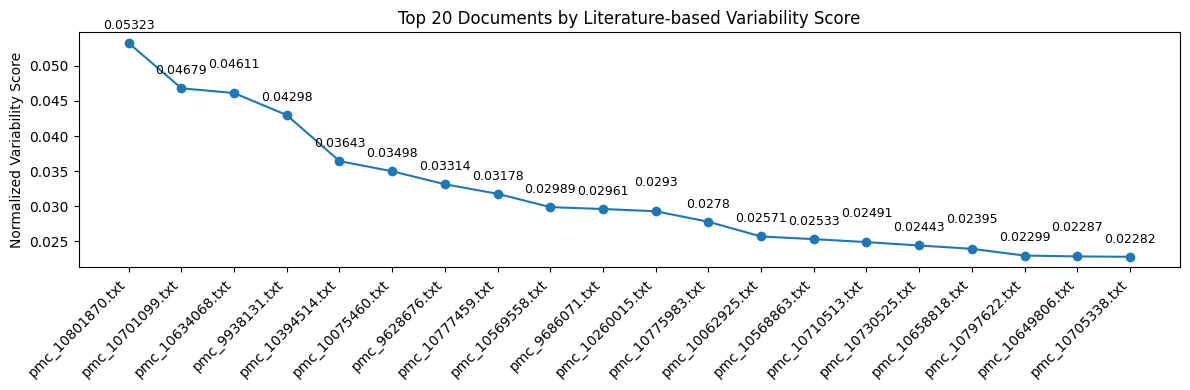

Saved (A): /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/variability_score_240126/FigureA_top20_variability_score_line.png
Saved (A): /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/variability_score_240126/FigureA_top20_variability_score_line.pdf
Saved (B) table: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/variability_score_240126/Table_doc_phrase_TF_top30x10.csv


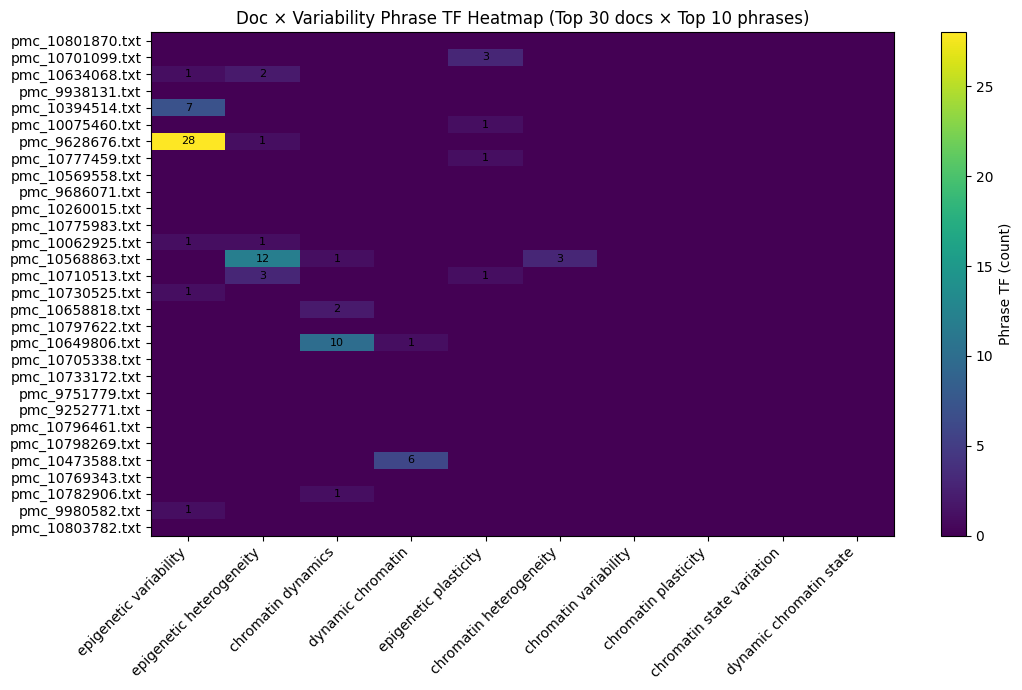

Saved (B): /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/variability_score_240126/FigureB_doc_phrase_TF_heatmap_top30x10.png
Saved (B): /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/variability_score_240126/FigureB_doc_phrase_TF_heatmap_top30x10.pdf
Saved (C) correlation matrix: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/variability_score_240126/Table_group_score_correlation_matrix.csv


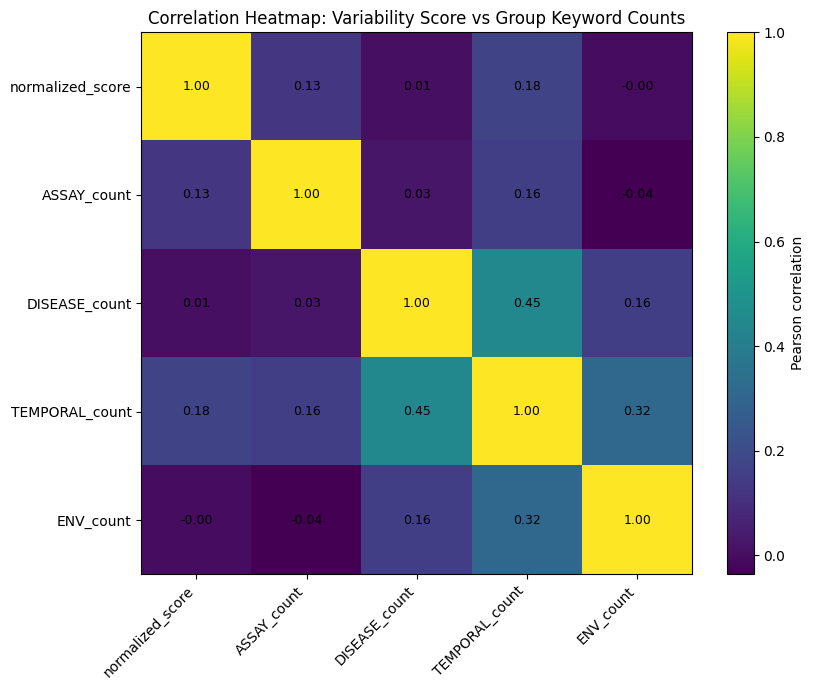

Saved (C): /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/variability_score_240126/FigureC_group_score_correlation_heatmap.png
Saved (C): /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/variability_score_240126/FigureC_group_score_correlation_heatmap.pdf

 DONE. All outputs saved in: /content/drive/MyDrive/Epigenomics_corpus/outputs_240126/variability_score_240126


In [ ]:
# =========================
# Google Drive 마운트 (Colab에서 Drive 접근)
# =========================
from google.colab import drive
drive.mount("/content/drive")

import os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) 경로
# =========================
# 9번째 점수 산출 코드에서 만든 결과 폴더
OUT_DIR = "/content/drive/MyDrive/Epigenomics_corpus/outputs_240126/variability_score_240126"
os.makedirs(OUT_DIR, exist_ok=True)

# 문서별 variability score CSV(이전 단계 산출물)
IN_CSV = os.path.join(OUT_DIR, "variability_score_per_doc.csv")

# (필요 시) 원문 텍스트(.txt) 폴더
# - (B) 히트맵에서 phrase TF를 원문에서 다시 계산하기 위해 사용
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"

# =========================
# 2) 용어(TERMS) / 그룹(GROUPS) 정의
# =========================
# variability 구문(phrase) 패턴: 문서 내에서 정확히 이 문구가 몇 번 나오는지 세기 위함
variability_patterns = [
    "chromatin variability",
    "chromatin heterogeneity",
    "dynamic chromatin",
    "chromatin plasticity",
    "chromatin state variation",
    "epigenetic variability",
    "epigenetic plasticity",
    "epigenetic heterogeneity",
    "chromatin dynamics",
    "dynamic chromatin state",
    "chromatin state variability"
]

# (C) 상관분석에서 사용할 그룹 키워드(문서에서 등장 횟수를 카운트)
assay_keywords = [
    "5C", "ChIA-PET", "Hi-C", "DNase-seq", "FAIRE-seq", "ATAC-seq", "ChIP-seq",
    "WGBS", "RRBS", "methylation array", "Computational", "predictions",
    "RNA-seq", "CLIP-seq", "RIP-seq", "Histone Modification"
]

disease_keywords = [
    "cancer", "tumor", "carcinoma",
    "diabetes",
    "alzheimer", "parkinson",
    "schizophrenia", "autism"
]

temporal_terms = ["development", "aging", "dynamic", "temporal", "progression"]

environmental_terms = [
    "smoking", "tobacco",
    "diet", "nutrition", "high-fat diet",
    "stress", "psychological stress",
    "pollution", "air pollution", "pm2.5",
    "toxin", "toxic exposure",
    "heavy metal", "lead", "cadmium",
    "environmental exposure"
]

# 그룹 딕셔너리: 그룹별 등장 횟수(빈도) 계산에 사용
group_terms = {
    "ASSAY": assay_keywords,
    "DISEASE": disease_keywords,
    "TEMPORAL": temporal_terms,
    "ENV": environmental_terms
}

# =========================
# 3) 점수 CSV 로드
# =========================
df = pd.read_csv(IN_CSV)

# normalized_score(정규화 점수) 높은 문서부터 정렬
df = df.sort_values("normalized_score", ascending=False).reset_index(drop=True)

print("Loaded:", IN_CSV)
print("Docs:", len(df))

# =========================
# 4) (A) TOP 20 라인 플롯 + 값 라벨
# =========================
TOP_N = 20
top20 = df.head(TOP_N).copy()

# x축 라벨에 파일명이 너무 길 수 있으므로 일정 길이로 줄여 표시
def short_name(fn, maxlen=25):
    fn = str(fn)
    return fn if len(fn) <= maxlen else fn[:maxlen-3] + "..."

x_labels = [short_name(f) for f in top20["file"].tolist()]     # x축 라벨(파일명 축약)
y = top20["normalized_score"].values                           # y축 값(정규화 variability score)

plt.figure(figsize=(12, 4))
x = np.arange(len(x_labels))
plt.plot(x, y, marker="o")
plt.xticks(x, x_labels, rotation=45, ha="right")
plt.ylabel("Normalized Variability Score")
plt.title(f"Top {TOP_N} Documents by Literature-based Variability Score")

# 값 라벨 겹침 최소화:
# - 기본 offset(살짝 위에 표시)
# - 이웃 값이 너무 비슷하면 번갈아 더 위로 띄우기
ymax = max(y) if len(y) else 1
base_offset = max(1e-8, ymax * 0.03)

for i, val in enumerate(y):
    dy = base_offset
    if i > 0 and abs(val - y[i-1]) <= ymax * 0.02:
        dy = base_offset * (2 if i % 2 == 0 else 1)
    plt.text(i, val + dy, f"{val:.4g}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()

figA_png = os.path.join(OUT_DIR, f"FigureA_top{TOP_N}_variability_score_line.png")
figA_pdf = os.path.join(OUT_DIR, f"FigureA_top{TOP_N}_variability_score_line.pdf")
plt.savefig(figA_png, dpi=600)
plt.savefig(figA_pdf)
plt.show()

print("Saved (A):", figA_png)
print("Saved (A):", figA_pdf)

# =========================
# 5) (B) 문서 × phrase TF 히트맵
# - Top 30 docs × Top 10 phrases
# - phrase TF는 원문(.txt)에서 다시 계산(정확)
# =========================
TOP_DOCS = 30
TOP_PHRASES = 10

# 상위 TOP_DOCS 문서 파일명 목록(정규화 점수 상위)
top_docs = df.head(TOP_DOCS)["file"].tolist()

# helper: 원문 텍스트 파일을 읽어서 소문자로 반환
def read_doc_text(filename):
    fp = os.path.join(CORPUS_DIR, filename)
    with open(fp, "r", encoding="utf-8", errors="ignore") as f:
        return f.read().lower()

# Top 문서별로 variability_patterns 각각이 몇 번 나오는지(phrase TF) 행을 만든다
phrase_tf_rows = []
for fn in top_docs:
    text_lower = read_doc_text(fn)
    row = {"file": fn}
    for p in variability_patterns:
        row[p] = text_lower.count(p.lower())   # 해당 phrase의 문서 내 등장 횟수
    phrase_tf_rows.append(row)

phrase_tf_df = pd.DataFrame(phrase_tf_rows)

# phrase별 전체 합(Top 문서군 전체에서 많이 나온 phrase) 기준으로 Top 10 phrase 선정
phrase_sums = phrase_tf_df[variability_patterns].sum(axis=0).sort_values(ascending=False)
top_phrases = phrase_sums.head(TOP_PHRASES).index.tolist()

# 히트맵에 쓸 데이터프레임(파일명 + top_phrases 열)
heat_df = phrase_tf_df[["file"] + top_phrases].copy()

# 히트맵 테이블 CSV 저장(논문 표로도 활용 가능)
out_heat_csv = os.path.join(OUT_DIR, f"Table_doc_phrase_TF_top{TOP_DOCS}x{TOP_PHRASES}.csv")
heat_df.to_csv(out_heat_csv, index=False, encoding="utf-8-sig")
print("Saved (B) table:", out_heat_csv)

# 히트맵용 행렬(숫자 부분만)
mat = heat_df[top_phrases].values

plt.figure(figsize=(11, 7))
im = plt.imshow(mat, aspect="auto")
plt.colorbar(im, label="Phrase TF (count)")

plt.xticks(np.arange(len(top_phrases)), top_phrases, rotation=45, ha="right")
plt.yticks(np.arange(len(top_docs)), [short_name(f, 30) for f in top_docs])

plt.title(f"Doc × Variability Phrase TF Heatmap (Top {TOP_DOCS} docs × Top {TOP_PHRASES} phrases)")

# 셀 값 표시(0은 생략)
threshold = 1
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        val = int(mat[i, j])
        if val >= threshold:
            plt.text(j, i, str(val), ha="center", va="center", fontsize=8)

plt.tight_layout()

figB_png = os.path.join(OUT_DIR, f"FigureB_doc_phrase_TF_heatmap_top{TOP_DOCS}x{TOP_PHRASES}.png")
figB_pdf = os.path.join(OUT_DIR, f"FigureB_doc_phrase_TF_heatmap_top{TOP_DOCS}x{TOP_PHRASES}.pdf")
plt.savefig(figB_png, dpi=600)
plt.savefig(figB_pdf)
plt.show()

print("Saved (B):", figB_png)
print("Saved (B):", figB_pdf)

# =========================
# 6) (C) 그룹 키워드 카운트 vs 점수 상관 히트맵
# - 각 문서에서 그룹 키워드 등장 횟수(count) 계산
# - normalized_score와의 Pearson 상관계수 행렬을 시각화
# =========================

# 전체 문서를 대상으로 상관을 계산하는 것이 일반적으로 안정적
# (시간이 오래 걸리면 상위 N개만 대상으로 제한 가능)
USE_TOP_N_FOR_GROUP = None  # None이면 전체, 숫자면 상위 N 문서만

if USE_TOP_N_FOR_GROUP is None:
    target_files = df["file"].tolist()
    target_scores = df["normalized_score"].values
else:
    target_files = df.head(USE_TOP_N_FOR_GROUP)["file"].tolist()
    target_scores = df.head(USE_TOP_N_FOR_GROUP)["normalized_score"].values

# helper: 한 문서에서 특정 그룹 terms가 총 몇 번 등장하는지(단순 count 합)
def group_count(text_lower, terms):
    s = 0
    for t in terms:
        s += text_lower.count(t.lower())
    return s

# 문서별 그룹 feature 테이블 생성
group_rows = []
for fn, sc in zip(target_files, target_scores):
    text_lower = read_doc_text(fn)
    row = {"file": fn, "normalized_score": sc}
    for g, terms in group_terms.items():
        row[f"{g}_count"] = group_count(text_lower, terms)          # 등장 횟수(연속형)
        row[f"{g}_has"] = int(row[f"{g}_count"] > 0)               # 등장 여부(0/1)
    group_rows.append(row)

group_df = pd.DataFrame(group_rows)

# 상관은 count 기반으로 수행(연속형이므로 해석이 단순)
corr_cols = ["normalized_score"] + [f"{g}_count" for g in group_terms.keys()]
corr = group_df[corr_cols].corr(method="pearson")

# 상관행렬 CSV 저장
out_corr_csv = os.path.join(OUT_DIR, "Table_group_score_correlation_matrix.csv")
corr.to_csv(out_corr_csv, encoding="utf-8-sig")
print("Saved (C) correlation matrix:", out_corr_csv)

# 상관 히트맵 표시(셀 값 포함)
corr_mat = corr.values
labels = corr.columns.tolist()

plt.figure(figsize=(8.5, 7))
im = plt.imshow(corr_mat, aspect="auto")
plt.colorbar(im, label="Pearson correlation")

plt.xticks(np.arange(len(labels)), labels, rotation=45, ha="right")
plt.yticks(np.arange(len(labels)), labels)

plt.title("Correlation Heatmap: Variability Score vs Group Keyword Counts")

# 셀마다 상관계수 수치 표시(예: 0.32, -0.10 등)
for i in range(corr_mat.shape[0]):
    for j in range(corr_mat.shape[1]):
        plt.text(j, i, f"{corr_mat[i, j]:.2f}", ha="center", va="center", fontsize=9)

plt.tight_layout()

figC_png = os.path.join(OUT_DIR, "FigureC_group_score_correlation_heatmap.png")
figC_pdf = os.path.join(OUT_DIR, "FigureC_group_score_correlation_heatmap.pdf")
plt.savefig(figC_png, dpi=600)
plt.savefig(figC_pdf)
plt.show()

print("Saved (C):", figC_png)
print("Saved (C):", figC_pdf)

print("\n DONE. All outputs saved in:", OUT_DIR)